# SPARK DATA ANALYSIS

This notebook is adapted from the course 'Ensemble Methods' by Cambridge Spark. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import sem
from numpy.random import permutation
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import mean_squared_error

First a look at the distribution of outcome variables.

In [4]:
dfreg2 = pd.read_csv("dfreg2.csv", index_col=0)
dfreg2.head()

,IID,ADHD,DBD,registration_year
1,SP0000057,0,0,2015
2,SP0000078,0,0,2015
3,SP0000104,1,0,2016
4,SP0000145,0,0,2016
5,SP0000162,0,0,2015


In [6]:
# Get number of rows
num_rows = dfreg2.shape[0]
print("Number of rows:", num_rows)

Number of rows: 13290


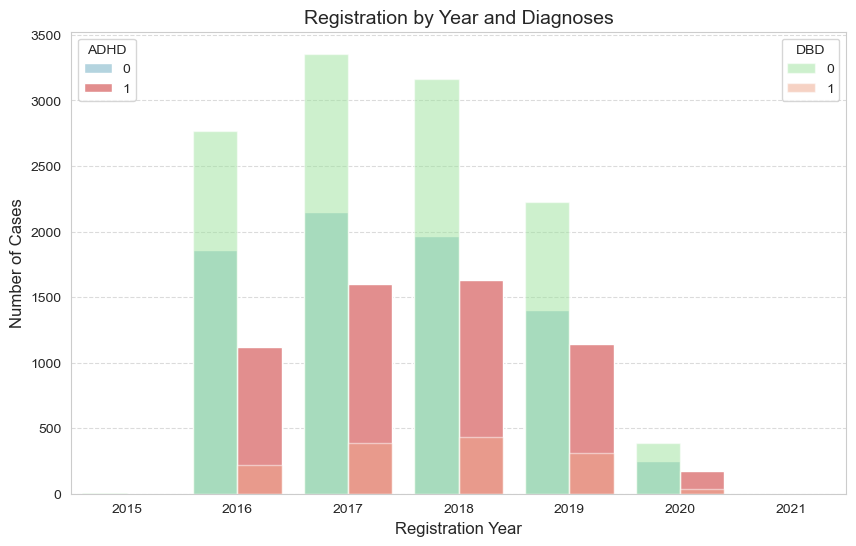

In [8]:
# Set plot style
sns.set_style("whitegrid")

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot by Sex
ax = sns.countplot(
    data=dfreg2, x="registration_year", hue="ADHD",
    palette=["lightblue", "lightcoral"], dodge=True
)

# Overlay plot by Subject with transparency
ax2 = sns.countplot(
    data=dfreg2, x="registration_year", hue="DBD",
    palette=["lightgreen", "lightsalmon"], dodge=True, alpha=0.5
)

# Extract handles and labels for both legends
handles1, labels1 = ax.get_legend_handles_labels()  
handles2, labels2 = ax2.get_legend_handles_labels()  

# Remove duplicate legends (as they overlap)
ax.get_legend().remove()

# Create two separate legends
legend1 = plt.legend(handles=handles1[:2], labels=labels1[:2], title="ADHD", loc="upper left")
legend2 = plt.legend(handles=handles2[2:], labels=labels2[2:], title="DBD", loc="upper right")


# Add legends back to the plot
plt.gca().add_artist(legend1)

# Customize labels and title
plt.xlabel("Registration Year", fontsize=12)
plt.ylabel("Number of Cases", fontsize=12)
plt.title("Registration by Year and Diagnoses", fontsize=14)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


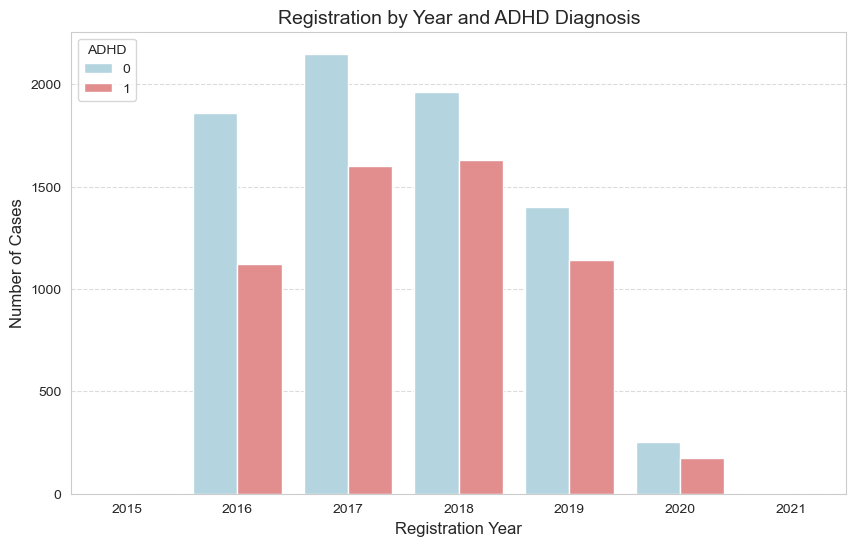

In [10]:
#For ADHD alone: 
# Set plot style
sns.set_style("whitegrid")

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot only ADHD by registration year
ax = sns.countplot(
    data=dfreg2, 
    x="registration_year", 
    hue="ADHD",
    palette=["lightblue", "lightcoral"], 
    dodge=True
)

# Customize labels and title
plt.xlabel("Registration Year", fontsize=12)
plt.ylabel("Number of Cases", fontsize=12)
plt.title("Registration by Year and ADHD Diagnosis", fontsize=14)

# Adjust legend
plt.legend(title="ADHD", loc="upper left")

# Improve readability
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save and show the plot
plt.savefig("adhd_plot.png", dpi=300, bbox_inches='tight')
plt.show()


Next I need to bring in my training data. This is 80% of the whole dataset, obtained using stratified train-test split with the caret package in R. The DBD column was used for stratification as this is a smaller sample and more likely to be unbalanced. 

In [11]:
sp2train = pd.read_csv("sp2train.csv", index_col=0)
sp2train.head()

,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ADHD,DBD
1,4,Female,False,-0.560344,-0.426153,0.584900,-0.002323,-0.001309,0.000464,-0.000605,0.000270,0.000040,0.001147,0.000553,-0.002719,-0.000654,0,0
2,12,Female,False,-1.518976,0.558775,1.086295,-0.002693,-0.000653,0.000217,-0.000719,-0.000843,-0.001115,-0.003306,-0.002642,0.003098,0.001341,0,0
3,16,Male,False,0.706432,1.730454,1.926706,-0.003537,0.000367,0.000679,-0.000091,0.001149,0.000779,-0.000304,-0.000133,-0.002932,-0.000422,1,0
4,13,Male,False,0.003648,-0.269015,-1.548828,-0.002431,0.003968,0.001356,0.000322,-0.000762,-0.006105,-0.009550,-0.006573,0.001344,0.002037,0,0
5,4,Male,False,-1.065770,-0.598608,-0.319585,0.003148,0.008511,0.000102,-0.000200,-0.000080,-0.004395,-0.008127,0.001091,-0.000962,-0.001803,0,0


In [13]:
#Look at the info.
info = sp2train.info()
print(info)

<class 'pandas.core.frame.DataFrame'>
Index: 10632 entries, 1 to 13290
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age_at_registration_years    10632 non-null  int64  
 1   SEX                          10632 non-null  object 
 2   cognitive_impairment_latest  10632 non-null  bool   
 3   normscoreadhd                10632 non-null  float64
 4   normscoredep                 10632 non-null  float64
 5   normscoredu                  10632 non-null  float64
 6   X1                           10632 non-null  float64
 7   X2                           10632 non-null  float64
 8   X3                           10632 non-null  float64
 9   X4                           10632 non-null  float64
 10  X5                           10632 non-null  float64
 11  X6                           10632 non-null  float64
 12  X7                           10632 non-null  float64
 13  X8                   

In [15]:
#Check if you have missing data
sp2train_nas_check_per_column = sp2train.isna().any()

# Display the result
print(sp2train_nas_check_per_column)

age_at_registration_years      False
SEX                            False
cognitive_impairment_latest    False
normscoreadhd                  False
normscoredep                   False
normscoredu                    False
X1                             False
X2                             False
X3                             False
X4                             False
X5                             False
X6                             False
X7                             False
X8                             False
X9                             False
X10                            False
ADHD                           False
DBD                            False
dtype: bool


In [17]:
#Use robust scaler for the age column, and head to check 
from sklearn.preprocessing import RobustScaler
# Select the column to scale
G = sp2train[['age_at_registration_years']]
# Fit and transform using RobustScaler
transage = RobustScaler().fit(G)
sp2train[['age_at_registration_years']] = transage.transform(G)
# View the result
sp2train.head()


,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ADHD,DBD
1,-0.625,Female,False,-0.560344,-0.426153,0.584900,-0.002323,-0.001309,0.000464,-0.000605,0.000270,0.000040,0.001147,0.000553,-0.002719,-0.000654,0,0
2,0.375,Female,False,-1.518976,0.558775,1.086295,-0.002693,-0.000653,0.000217,-0.000719,-0.000843,-0.001115,-0.003306,-0.002642,0.003098,0.001341,0,0
3,0.875,Male,False,0.706432,1.730454,1.926706,-0.003537,0.000367,0.000679,-0.000091,0.001149,0.000779,-0.000304,-0.000133,-0.002932,-0.000422,1,0
4,0.500,Male,False,0.003648,-0.269015,-1.548828,-0.002431,0.003968,0.001356,0.000322,-0.000762,-0.006105,-0.009550,-0.006573,0.001344,0.002037,0,0
5,-0.625,Male,False,-1.065770,-0.598608,-0.319585,0.003148,0.008511,0.000102,-0.000200,-0.000080,-0.004395,-0.008127,0.001091,-0.000962,-0.001803,0,0


In [19]:
# First I need to convert SEX and cognitive_impairment_latest to 0/1

sp2train['SEX'] = sp2train['SEX'].map({'Male': 0, 'Female': 1})

sp2train['cognitive_impairment_latest'] = sp2train['cognitive_impairment_latest'].astype(int)

sp2train.head()

,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ADHD,DBD
1,-0.625,1,0,-0.560344,-0.426153,0.584900,-0.002323,-0.001309,0.000464,-0.000605,0.000270,0.000040,0.001147,0.000553,-0.002719,-0.000654,0,0
2,0.375,1,0,-1.518976,0.558775,1.086295,-0.002693,-0.000653,0.000217,-0.000719,-0.000843,-0.001115,-0.003306,-0.002642,0.003098,0.001341,0,0
3,0.875,0,0,0.706432,1.730454,1.926706,-0.003537,0.000367,0.000679,-0.000091,0.001149,0.000779,-0.000304,-0.000133,-0.002932,-0.000422,1,0
4,0.500,0,0,0.003648,-0.269015,-1.548828,-0.002431,0.003968,0.001356,0.000322,-0.000762,-0.006105,-0.009550,-0.006573,0.001344,0.002037,0,0
5,-0.625,0,0,-1.065770,-0.598608,-0.319585,0.003148,0.008511,0.000102,-0.000200,-0.000080,-0.004395,-0.008127,0.001091,-0.000962,-0.001803,0,0


In [21]:
#Recheck if you have missing data
sp2train_nas_check_per_column = sp2train.isna().any()

# Display the result
print(sp2train_nas_check_per_column)

age_at_registration_years      False
SEX                            False
cognitive_impairment_latest    False
normscoreadhd                  False
normscoredep                   False
normscoredu                    False
X1                             False
X2                             False
X3                             False
X4                             False
X5                             False
X6                             False
X7                             False
X8                             False
X9                             False
X10                            False
ADHD                           False
DBD                            False
dtype: bool


C:\Users\niran\AppData\Local\Temp\ipykernel_25404\431200894.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].astype(str), ax=axes[i], palette='Set2')  # Convert to string for countplot
C:\Users\niran\AppData\Local\Temp\ipykernel_25404\431200894.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].astype(str), ax=axes[i], palette='Set2')  # Convert to string for countplot
C:\Users\niran\AppData\Local\Temp\ipykernel_25404\431200894.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].astype(str), ax=axes

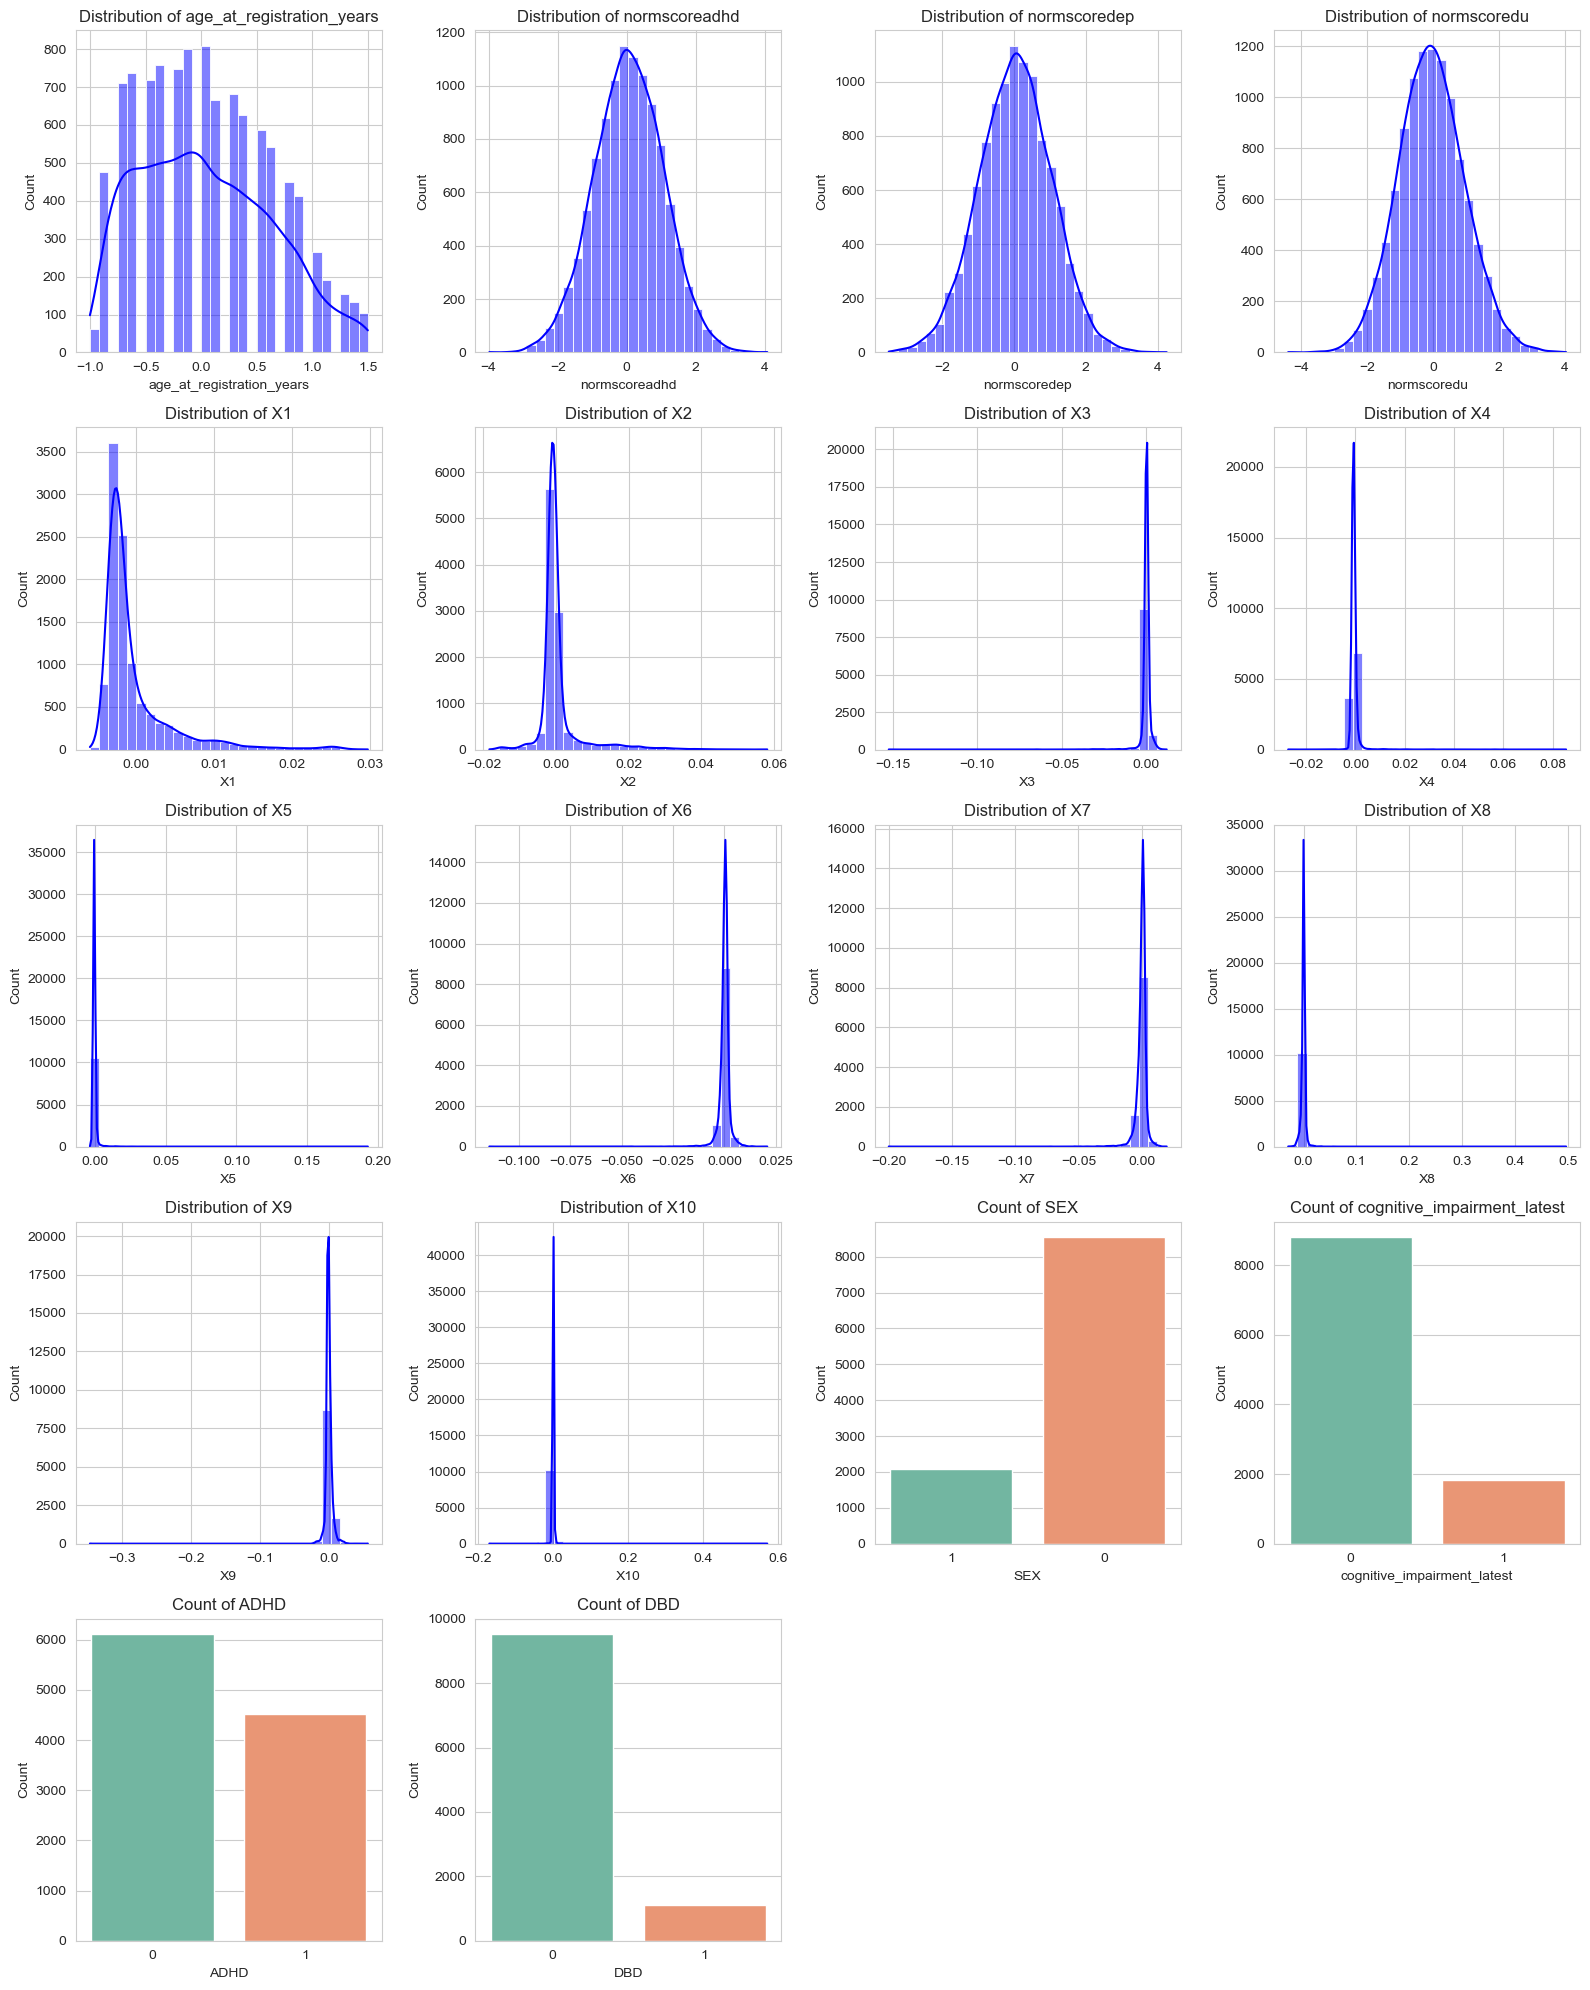

In [23]:
#Plot distributions of all variables

def plot_all_distributions(df, bins=30):
    numeric_cols = df.select_dtypes(include=['number']).columns
    binary_cols = [col for col in numeric_cols if df[col].nunique() == 2]
    continuous_cols = [col for col in numeric_cols if df[col].nunique() > 2]
    
    total_plots = len(continuous_cols) + len(binary_cols)
    if total_plots == 0:
        print("No columns to plot.")
        return

    # Define number of columns for subplots
    n_cols = 4
    n_rows = (total_plots // n_cols) + (total_plots % n_cols > 0)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    i = 0
    # Plot continuous distributions
    for col in continuous_cols:
        sns.histplot(df[col], ax=axes[i], bins=bins, kde=True, color='blue')
        axes[i].set_title(f'Distribution of {col}')
        i += 1

    # Plot binary distributions as count plots
    for col in binary_cols:
        sns.countplot(x=df[col].astype(str), ax=axes[i], palette='Set2')  # Convert to string for countplot
        axes[i].set_title(f'Count of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        i += 1

    # Hide any unused axes
    for j in range(i, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_distributions(sp2train)



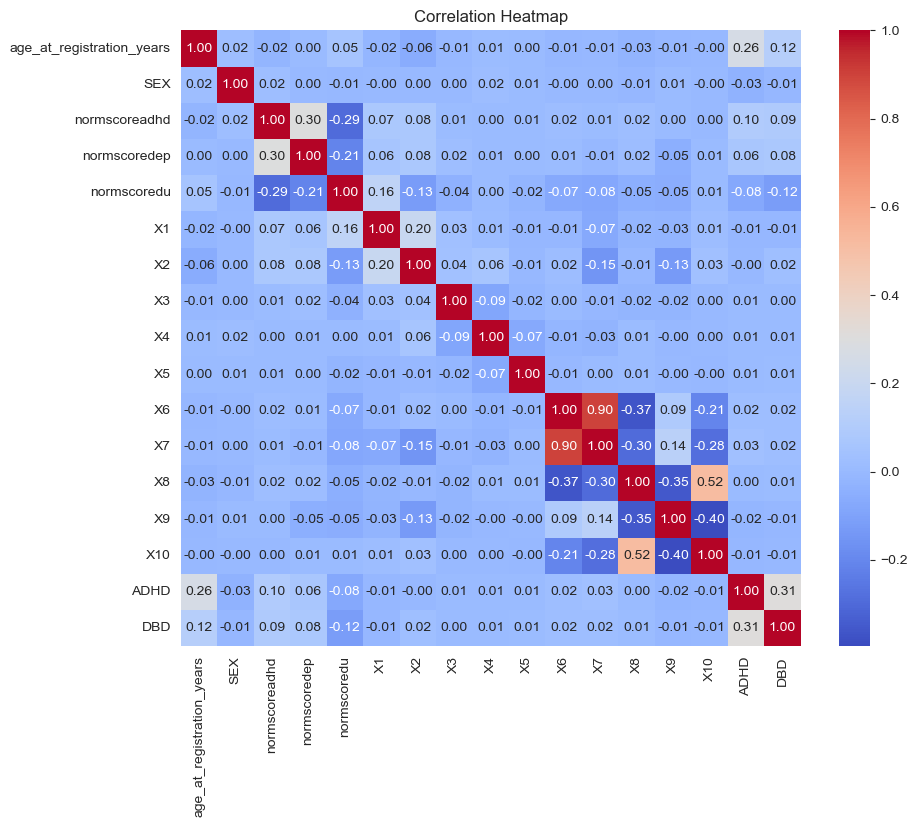

In [12]:
def plot_correlation_heatmap(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    if len(numeric_cols) < 2:
        print("Not enough numeric columns to calculate correlations.")
        return
    
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()

plot_correlation_heatmap(sp2train)

Saved heatmap to corrheatmap_plot.png


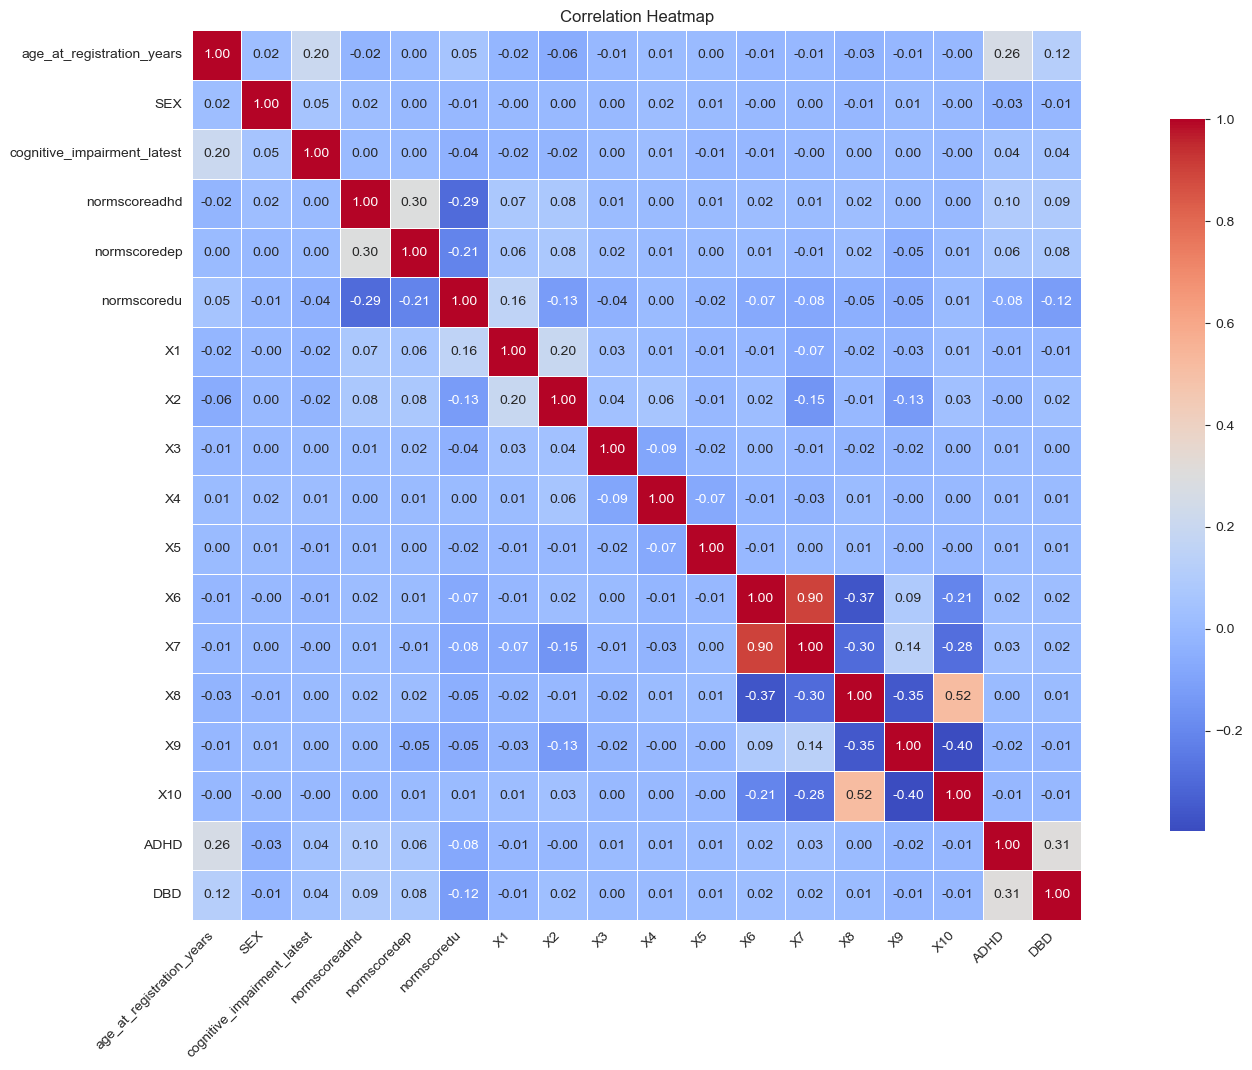

In [33]:
#Replot to include cimp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df, save_path=None):
    # Include all numeric columns
    numeric_cols = df.select_dtypes(include=['number', 'bool']).columns
    
    if len(numeric_cols) < 2:
        print("Not enough numeric columns to calculate correlations.")
        return
    
    # Use .corr() with numeric_only=True to ensure all numeric data are included
    corr = df[numeric_cols].corr(numeric_only=True)
    
    # Reindex to keep all numeric columns (even those with NaN correlations)
    corr = corr.reindex(index=numeric_cols, columns=numeric_cols)
    
    plt.figure(figsize=(max(8, len(numeric_cols)), max(6, len(numeric_cols)*0.6)))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True,
                cbar_kws={'shrink': 0.8}, linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved heatmap to {save_path}")
    
    plt.show()

#To deploy: 
plot_correlation_heatmap(sp2train, save_path="corrheatmap_plot.png")


### Prediction

Create an input data array `X` (with all columns except ADHD and DBD), and the output arrays y1 and y2. Set the output array to `float64` type.

In [13]:
# Modify code as required
#X, y = data.iloc[:,:-1].values, data.iloc[:,-1].values
X = sp2train.iloc[:, :-2].values  # Select all columns except the last two
y1 = sp2train.iloc[:, -2].values  # Second to last column [ADHD]
y2 = sp2train.iloc[:, -1].values  # Last column [DBD]

y1 = y1.astype('int')
y2 = y2.astype('int')

Print how many rows and columns your input array contains.

In [14]:
X.shape

(10632, 16)

Divide your input data into 10-fold cross-validation sets, using the `KFold` method. Assign it to the variable `cv`.


In [15]:
cv = KFold(n_splits=10, shuffle=False)

### Training multiple classifiers: ADHD

Let's start by training different kinds of classifiers, which we will bundle together later.

Train a Logistic Regression model by iterating over the 10-fold data split you created, fitting a model to the training data, and calculating the prediction error for the test data. Use the `accuracy()` metric. 

Save the final scores to `scores_logreg` and print it.

In [43]:
# Let's run this for y1
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import accuracy_score
scores_logreg = []
for train_index, test_index in cv.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y1_train, y1_test = y1[train_index], y1[test_index]
    
    # Fit Logistic Regression model with class_weight='balanced'
    model_logreg = LogisticRegression(class_weight='balanced').fit(X_train, y1_train)

    # Predict using the model
    y1_pred = model_logreg.predict(X_test)

    # Calculate accuracy (you could also collect other metrics here)
    error = accuracy_score(y1_test, y1_pred)
    scores_logreg.append(error)

scores_logreg


[0.6174812030075187,
 0.6419172932330827,
 0.6086547507055503,
 0.6293508936970837,
 0.6030103480714958,
 0.6500470366886171,
 0.6180620884289746,
 0.6472248353715898,
 0.6444026340545626,
 0.6312323612417686]

Let's add some penalty with elastic net. 

In [46]:
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import accuracy_score
scores_elnet = []
for train_index, test_index in cv.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y1_train, y1_test = y1[train_index], y1[test_index]
    
    # Fit Elastic Net Logistic Regression model with class_weight='balanced'
    model_elnet = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        C=1.0,
        class_weight='balanced',
        max_iter=1000  # You may need this to ensure convergence
    )
    model_elnet.fit(X_train, y1_train)

    # Predict using the model
    y1_pred = model_elnet.predict(X_test)

    # Calculate accuracy (you could also collect other metrics)
    error = accuracy_score(y1_test, y1_pred)
    scores_elnet.append(error)

scores_elnet


[0.6174812030075187,
 0.6419172932330827,
 0.6077140169332079,
 0.6293508936970837,
 0.6030103480714958,
 0.6500470366886171,
 0.6180620884289746,
 0.6453433678269049,
 0.6444026340545626,
 0.6312323612417686]

Now let us train a random forest model. This time use the convenience method `cross_val_score()` that implements the cross-validation and scoring procedure. Save the final scores to `scores_rf` and print it.

In [49]:
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import cross_val_score
# Unified Random Forest model with class balancing and overfitting control
model_rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

# Cross-validated accuracy scores
scores_rf = cross_val_score(
    model_rf,
    X,
    y1,
    scoring='accuracy',
    cv=cv
)

scores_rf


array([0.56766917, 0.61184211, 0.60206961, 0.62558796, 0.61806209,
       0.64816557, 0.63405456, 0.64722484, 0.64816557, 0.67356538])

As a fourth model, train a gradient boosting classifier, again using the `cross_val_score()`. 

In [52]:
#!pip install xgboost
#Installing collected packages: xgboost
#Successfully installed xgboost-3.0.2

In [56]:
from sklearn.ensemble import GradientBoostingClassifier
#from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

# Create sample weights for each sample based on class balance
sample_weights = compute_sample_weight(class_weight='balanced', y=y1)

model_gb = GradientBoostingClassifier()

scores_gb = cross_val_score(
    model_gb,
    X,
    y1,
    scoring='accuracy',
    cv=cv,
    #fit_params={'sample_weight': sample_weights}
    params={'sample_weight': sample_weights}
)

scores_gb


array([0.59116541, 0.63345865, 0.60865475, 0.6406397 , 0.62464722,
       0.66792098, 0.63969897, 0.6491063 , 0.64158043, 0.68391345])

### Creating a Stacking ensemble

The Stacking method takes individual prediction models and combines their predictions through an additional model.

Create a Stacking model that combines the four types of models we have used and uses the gradient boosting model as the final layer. 

Set it up with a 5-fold cross-validation split. Note that this is the level-2 cross-validation split, which is different to the cross-validation of the dataset done at the start.

Fit and score the model with `cross_val_score()`. Save the scores to `score_stack` and print it.

In [72]:
#from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
#from sklearn.linear_model import LogisticRegression
#from sklearn.model_selection import cross_val_score
#import numpy as np
# Optional: compute class balance for reporting (not used by sklearn GB)
neg, pos = np.bincount(y1)
imbalance_ratio = neg / pos
print(f"Class imbalance ratio (neg:pos): {imbalance_ratio:.2f}:1")

sample_weights = compute_sample_weight(class_weight='balanced', y=y1)

#Base models
base_models = [
    ("logreg", LogisticRegression(class_weight="balanced")),
    ("elnet", LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        C=1.0,
        class_weight="balanced",
        max_iter=1000
    )),
    ("rf", RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42,
        #cv=cv
    )),
    ("gb", GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42,
        #cv=cv,
        #params={'sample_weight': sample_weights}
    ))
]

# Final estimator (meta-learner)
stack_gb = GradientBoostingClassifier()

# Stacking classifier
model_stack = StackingClassifier(
    estimators=base_models,
    final_estimator=stack_gb,
    cv=cv,
    #n_estimators=200,
)

# Cross-validation evaluation (accuracy only)
scores_stack = cross_val_score(
    model_stack,
    X,
    y1,
    scoring='accuracy',
    cv=cv
)

# Show cross-validated accuracy scores
scores_stack


Class imbalance ratio (neg:pos): 1.35:1


array([0.63909774, 0.64567669, 0.62746943, 0.6462841 , 0.62182502,
       0.65663217, 0.64158043, 0.66133584, 0.64158043, 0.65004704])

In [74]:
#Errors? 
error_scores = 1 - scores_stack
error_scores

array([0.36090226, 0.35432331, 0.37253057, 0.3537159 , 0.37817498,
       0.34336783, 0.35841957, 0.33866416, 0.35841957, 0.34995296])

In [76]:
# Mean accuracy?
np.mean(scores_logreg), np.mean(scores_elnet), np.mean(scores_rf), np.mean(scores_gb), np.mean(scores_stack)

(0.6291383444500245,
 0.6288561243183216,
 0.6276406856746759,
 0.6380785866359219,
 0.6431528904575644)

The Stacking model combined the predictions of the individual models. As some models give better predictions than others, this should be reflected in how the stacking model weights each of them.

To inspect this, create a Stacking model as above (or reuse it) and now fit it to the whole dataset X.

Print the final coefficients of the meta-learner layer, stored under .final_estimator_.coef_. Which model is given more weight and why?

Next we can plot the models

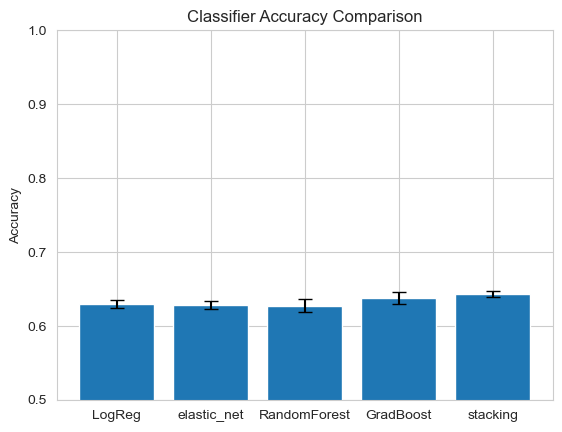

In [79]:
# Store scores in an array
scores = np.array([scores_logreg, scores_elnet, scores_rf, scores_gb, scores_stack])
labels = ["LogReg", "elastic_net", "RandomForest", "GradBoost", "stacking"]

# Plot accuracy scores with error bars
plt.bar(range(len(labels)), scores.mean(axis=1), yerr=sem(scores, axis=1), capsize=5)
plt.xticks(range(len(labels)), labels)
plt.ylim(0.5, 1.0)  # Adjust based on accuracy range
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.show()

logreg: Mean AUC = 0.677, Std = 0.018
Elastic Net: Mean AUC = 0.677, Std = 0.017
Random Forest: Mean AUC = 0.707, Std = 0.016
GradBoost: Mean AUC = 0.715, Std = 0.017
Stacking: Mean AUC = 0.707, Std = 0.016


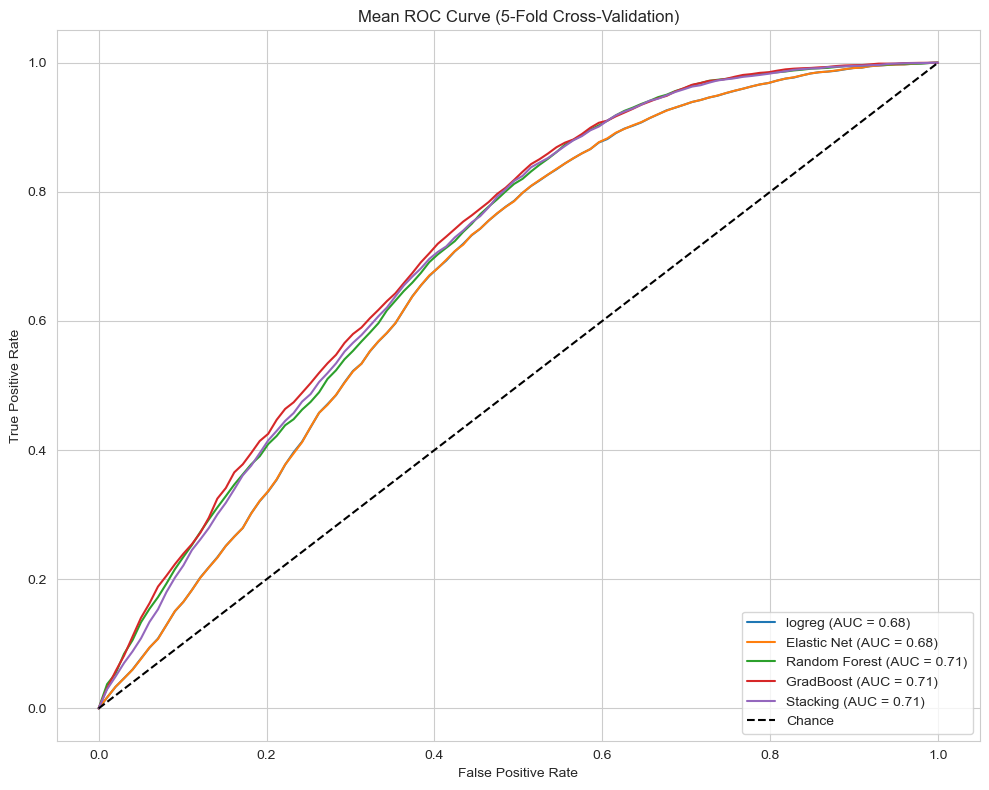

In [81]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Define all your models here
models = {
    "logreg": model_logreg,
    "Elastic Net": model_elnet,
    "Random Forest": model_rf,
    "GradBoost": model_gb,
    "Stacking": model_stack
}

# Cross-validation setup
cv = cv

# Plot setup
plt.figure(figsize=(10, 8))

# Iterate over all models
for name, model in models.items():
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X, y1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y1[train_idx], y1[test_idx]

        model.fit(X_train, y_train)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:  # fallback for models without predict_proba
            y_prob = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    # Print AUC stats
    print(f"{name}: Mean AUC = {mean_auc:.3f}, Std = {std_auc:.3f}")

    # Plot ROC curve
    plt.plot(mean_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.2f})")

# Finalize plot
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curve (5-Fold Cross-Validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

      
    

In [83]:
#Might be good to obtain more robust metrics for ADHD models.
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

# Evaluate models using out-of-fold predictions from cross-validation
def evaluate_cv_models(model_set, X, y, cv=5, set_name="Model Set"):
    print(f"\n--- Cross-Validated Evaluation for {set_name} ---")
    for name, model in model_set.items():
        # Get out-of-fold predicted probabilities or decision function
        if hasattr(model, "predict_proba"):
            y_prob = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
        else:
            y_prob = cross_val_predict(model, X, y, cv=cv, method='decision_function')

        # Get out-of-fold predicted labels
        y_pred = cross_val_predict(model, X, y, cv=cv)

        # Compute metrics
        auc = roc_auc_score(y, y_prob)
        f1 = f1_score(y, y_pred)
        bal_acc = balanced_accuracy_score(y, y_pred)

        print(f"{name}: AUC = {auc:.3f}, F1 = {f1:.3f}, Balanced Acc = {bal_acc:.3f}")

# models = {"logreg": model_logreg, "elnet": model_elnet, ...}
evaluate_cv_models(models, X, y1, cv=5, set_name="ADHD Models")



--- Cross-Validated Evaluation for ADHD Models ---
logreg: AUC = 0.678, F1 = 0.587, Balanced Acc = 0.629
Elastic Net: AUC = 0.678, F1 = 0.587, Balanced Acc = 0.629
Random Forest: AUC = 0.706, F1 = 0.661, Balanced Acc = 0.656
GradBoost: AUC = 0.712, F1 = 0.601, Balanced Acc = 0.644
Stacking: AUC = 0.705, F1 = 0.589, Balanced Acc = 0.635


Some additional plots to review these models.

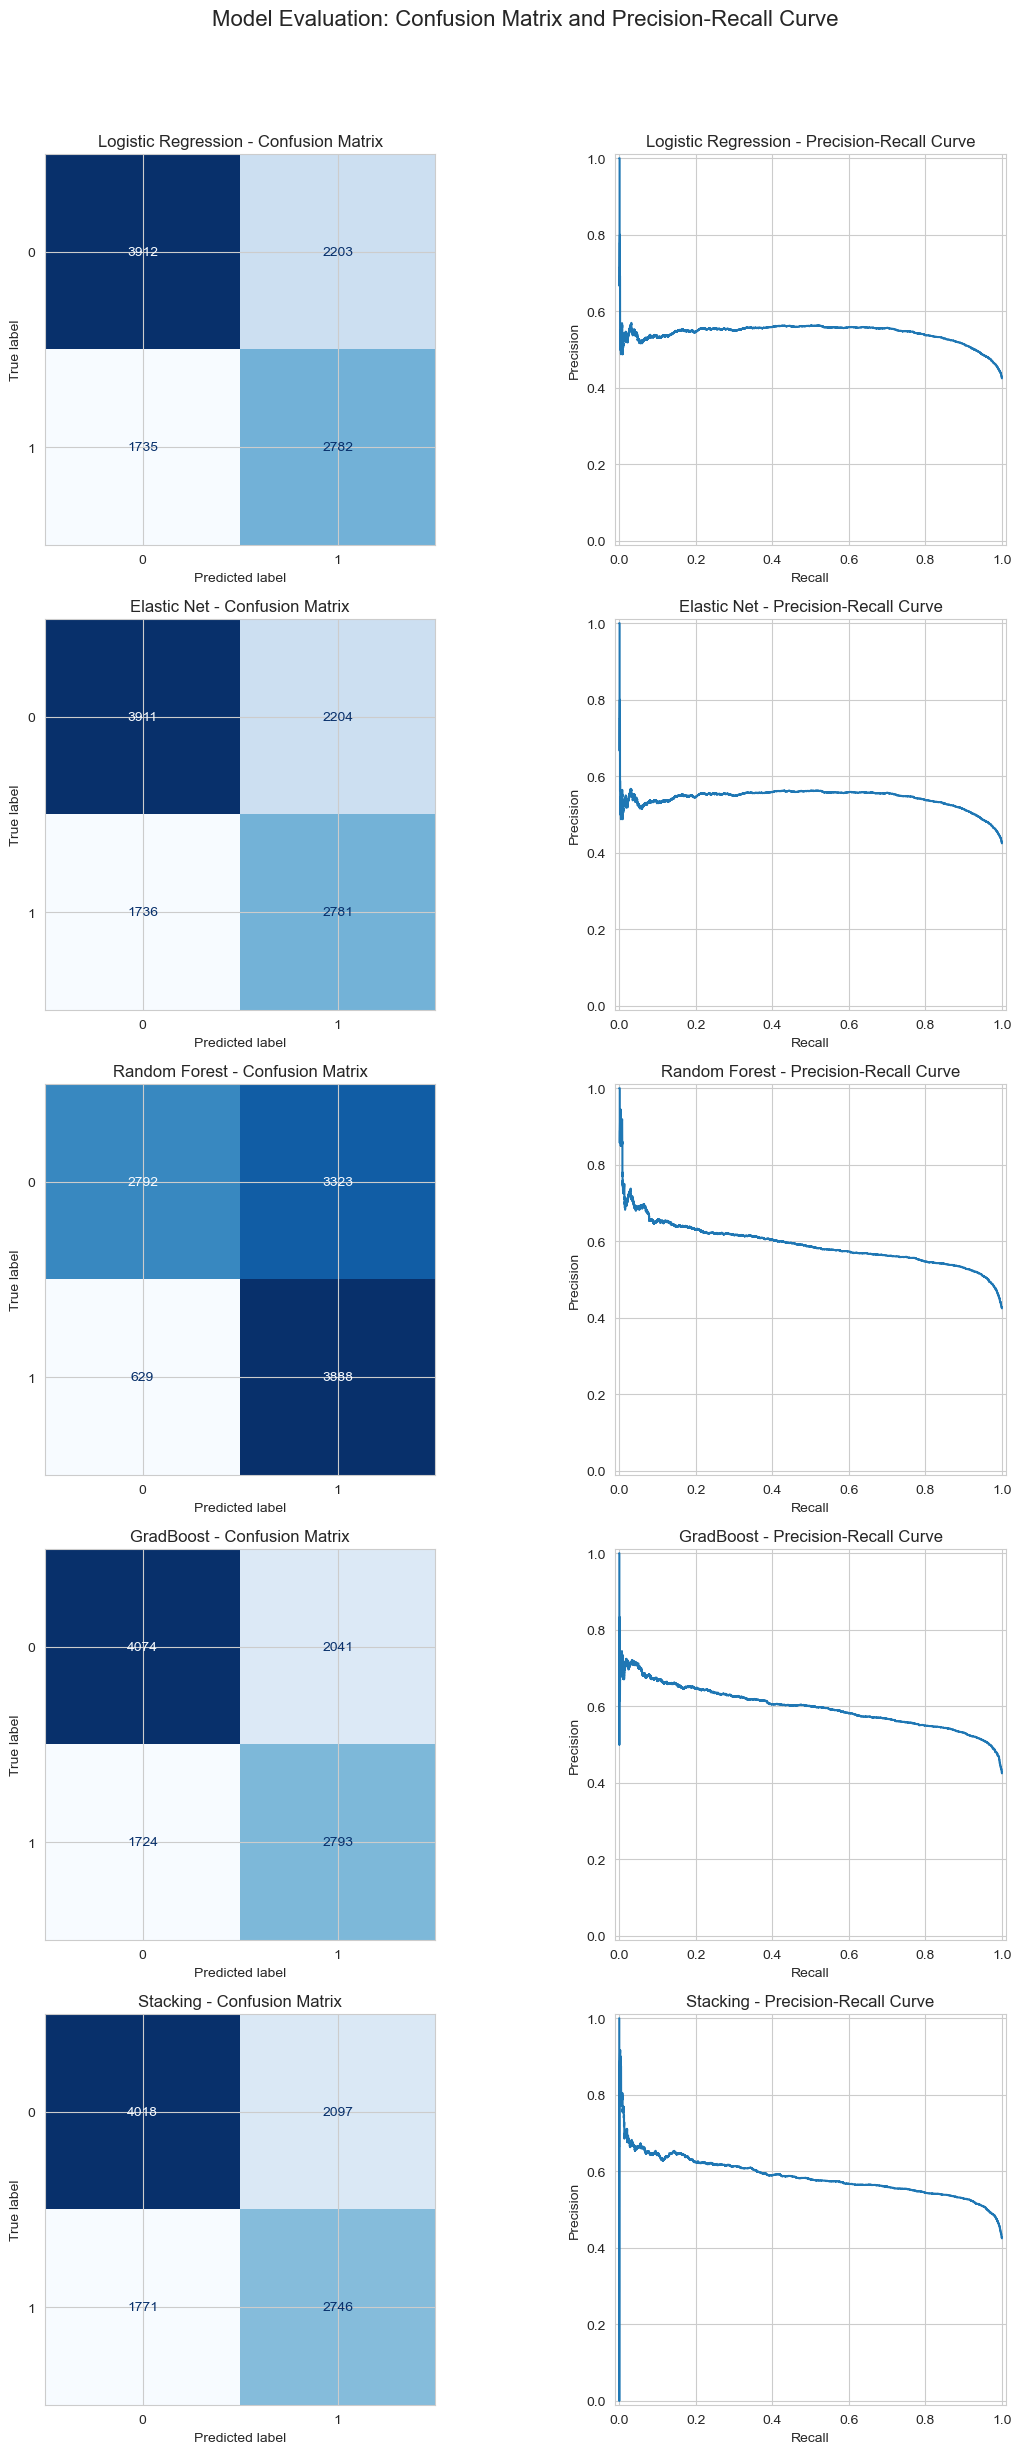

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, PrecisionRecallDisplay
)

# Define your models
models = {
    "Logistic Regression": model_logreg,
    "Elastic Net": model_elnet,
    "Random Forest": model_rf,
    "GradBoost": model_gb,
    "Stacking": model_stack
}

# Setup for plots
n_models = len(models)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))
fig.suptitle("Model Evaluation: Confusion Matrix and Precision-Recall Curve", fontsize=16)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (name, model) in enumerate(models.items()):
    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    for train_idx, test_idx in cv.split(X, y1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y1[train_idx], y1[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)
        y_prob_all.extend(y_prob)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_prob_all = np.array(y_prob_all)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true_all, y_pred_all)
    ConfusionMatrixDisplay(cm).plot(ax=axes[i, 0], cmap='Blues', colorbar=False)
    axes[i, 0].set_title(f"{name} - Confusion Matrix")

    # --- Precision-Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_true_all, y_prob_all)
    PrecisionRecallDisplay(precision=precision, recall=recall).plot(ax=axes[i, 1])
    axes[i, 1].set_title(f"{name} - Precision-Recall Curve")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Another look: 1) using parameter grid 2)stacking on random forest 3)Swapping GB with HistGradientBoostingClassifier. 

C:\Users\niran\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\niran\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\niran\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\niran\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\niran\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

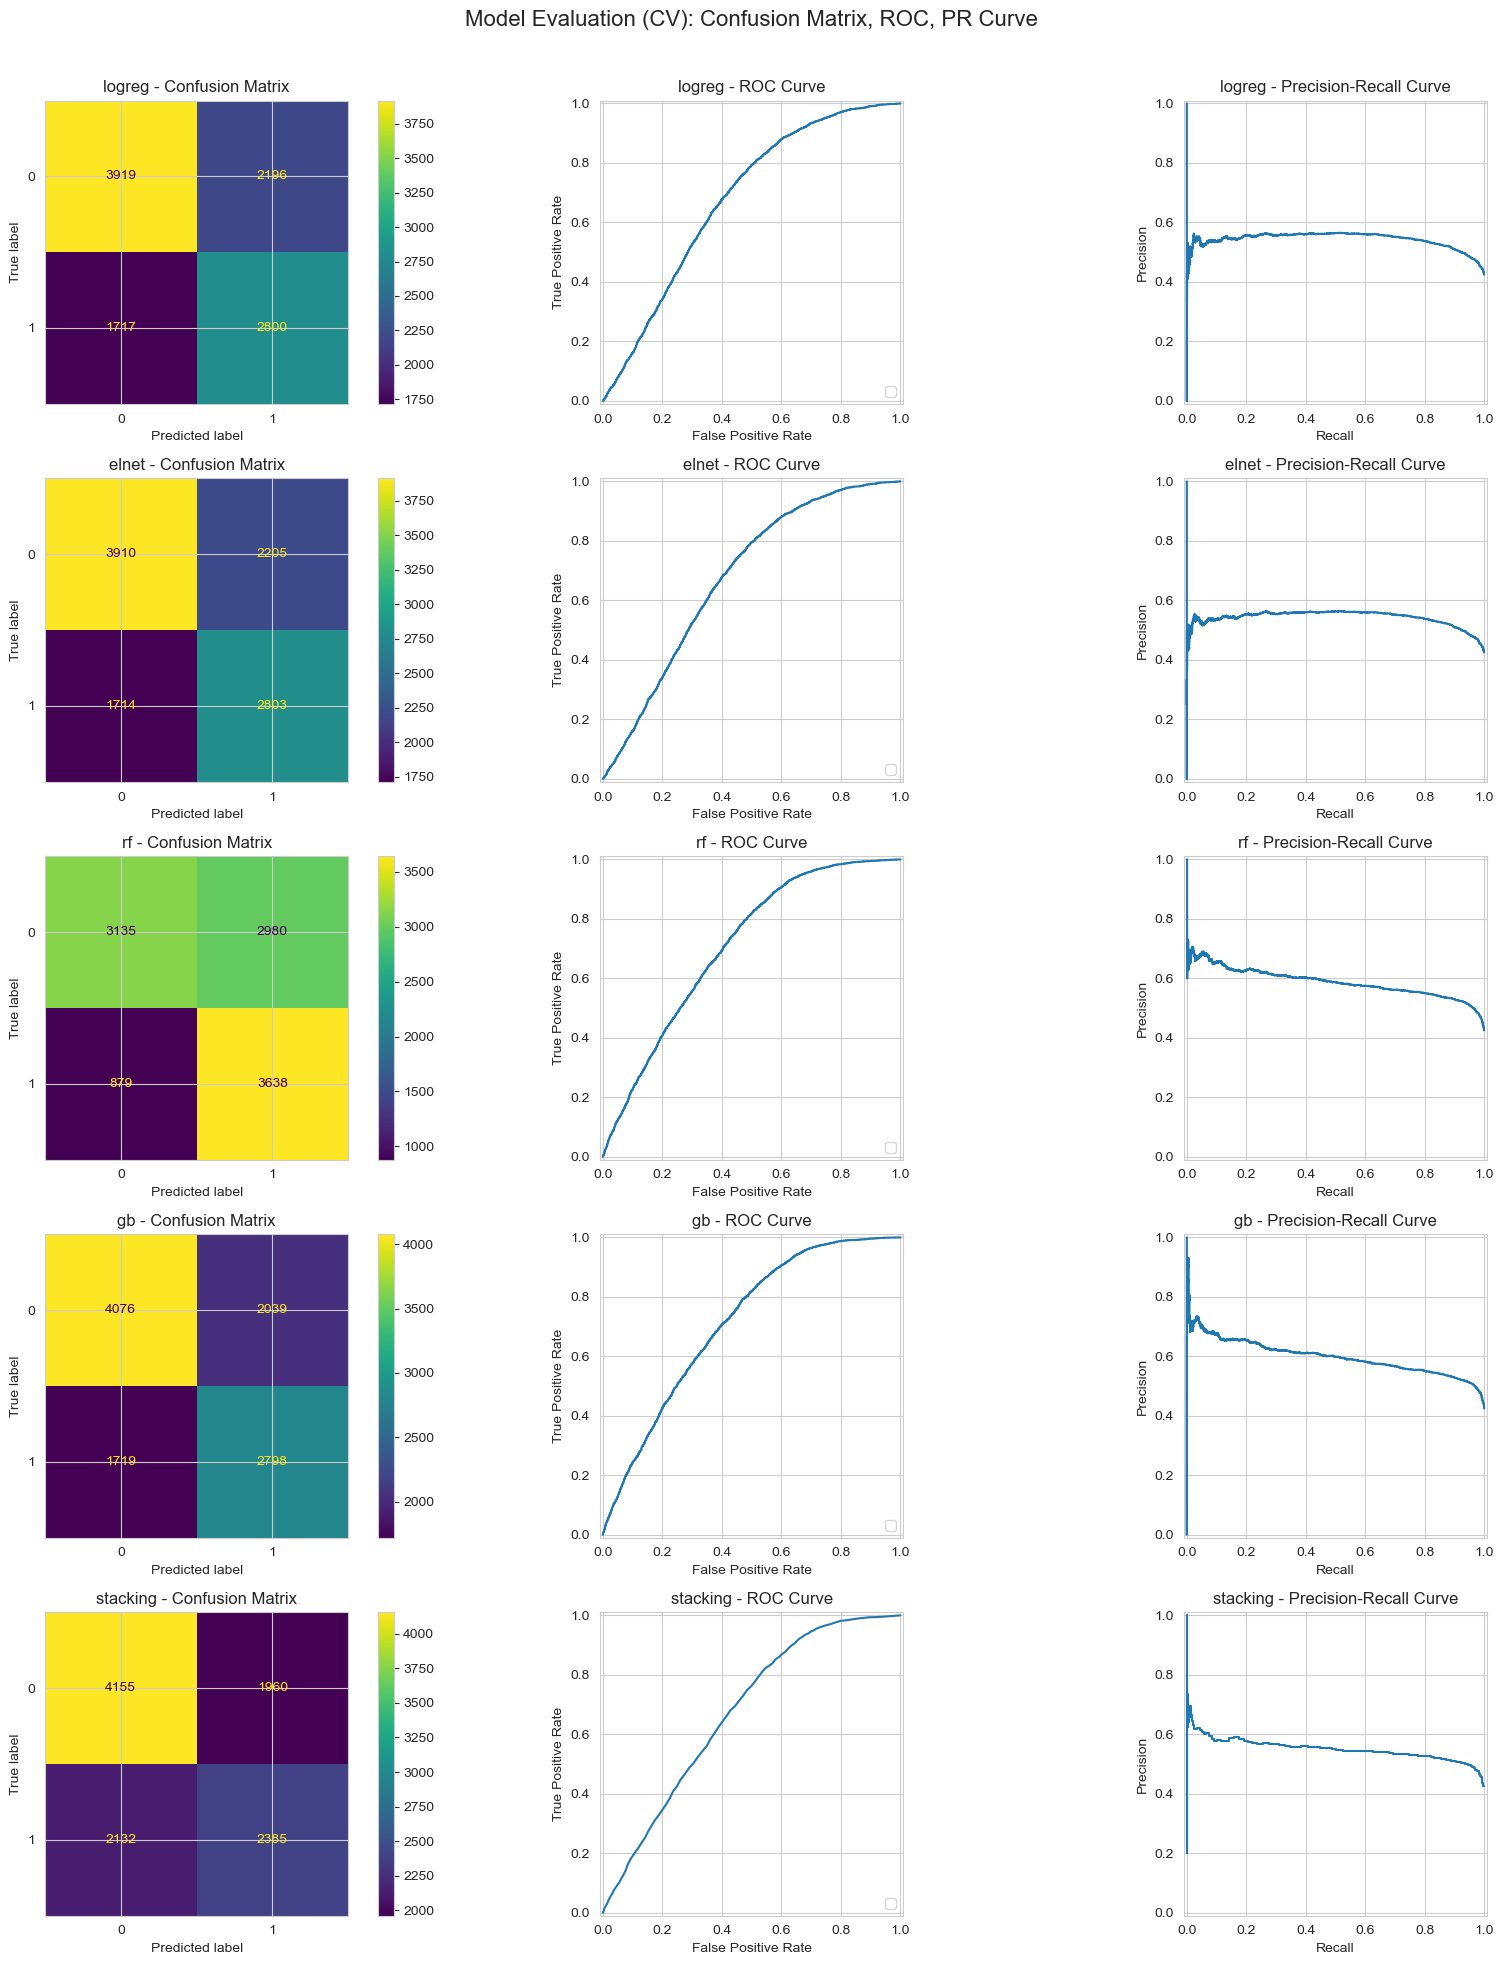

--- Model Evaluation Metrics for ADHD ---
logreg: AUC = 0.678, F1 = 0.589, Balanced Acc = 0.630
elnet: AUC = 0.678, F1 = 0.589, Balanced Acc = 0.630
rf: AUC = 0.707, F1 = 0.653, Balanced Acc = 0.659
gb: AUC = 0.714, F1 = 0.598, Balanced Acc = 0.643
stacking: AUC = 0.675, F1 = 0.534, Balanced Acc = 0.601


In [47]:
#UPDATED CODE USING PARAMETER GRIDS
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom GridSearchCV to inject sample_weight
class GridSearchCVWithSampleWeight(GridSearchCV):
    def fit(self, X, y, **fit_params):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)

        if hasattr(self.estimator, 'named_steps'):
            for step_name in self.estimator.named_steps:
                if hasattr(self.estimator.named_steps[step_name], 'fit'):
                    fit_params[f'{step_name}__sample_weight'] = sample_weight
        else:
            fit_params['sample_weight'] = sample_weight

        return super().fit(X, y, **fit_params)

# Models and parameter grids
param_grids = {
    "logreg": {
        "model": make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced")),
        "params": {
            "logisticregression__C": [0.01, 0.1, 1, 10]
        }
    },
    "elnet": {
        "model": make_pipeline(StandardScaler(), LogisticRegression(
            penalty="elasticnet", solver="saga", class_weight="balanced", max_iter=1000)),
        "params": {
            "logisticregression__l1_ratio": [0.1, 0.5, 0.9],
            "logisticregression__C": [0.1, 1, 10]
        }
    },
    "rf": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42),
        "params": {
            "n_estimators": [100],
            "max_depth": [3, 5, 10],
            "min_samples_leaf": [5, 10]
        }
    },
    "gb": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "max_iter": [100],
            "max_depth": [3, 5],
            "min_samples_leaf": [5, 10]
        }
    }
}

# Store trained models and metrics
trained_models = {}
metrics = {}

# Train each model with GridSearchCV and evaluate using cross_val_predict
for name, spec in param_grids.items():
    clf = GridSearchCVWithSampleWeight(spec["model"], spec["params"], cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    clf.fit(X, y1)
    trained_models[name] = clf.best_estimator_

    y_pred = cross_val_predict(clf.best_estimator_, X, y1, cv=cv)
    y_prob = cross_val_predict(clf.best_estimator_, X, y1, cv=cv, method="predict_proba")[:, 1]

    metrics[name] = {
        "F1": f1_score(y1, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y1, y_pred),
        "AUC": roc_auc_score(y1, y_prob)
    }

# Add stacking model with HistGradientBoostingClassifier as final estimator
stack_model = StackingClassifier(
    estimators=[
        ("logreg", clone(trained_models["logreg"])),
        ("elnet", clone(trained_models["elnet"])),
        ("rf", clone(trained_models["rf"])),
        ("gb", clone(trained_models["gb"]))
    ],
    final_estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    cv=cv
)

stack_model.fit(X, y1)
trained_models["stacking"] = stack_model

# Use cross_val_predict for stacking model
y_pred = cross_val_predict(stack_model, X, y1, cv=cv)
y_prob = cross_val_predict(stack_model, X, y1, cv=cv, method="predict_proba")[:, 1]
metrics["stacking"] = {
    "F1": f1_score(y1, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(y1, y_pred),
    "AUC": roc_auc_score(y1, y_prob)
}

# Plot metrics and curves
fig, axes = plt.subplots(len(trained_models), 3, figsize=(18, 4 * len(trained_models)))
fig.suptitle("Model Evaluation (CV): Confusion Matrix, ROC, PR Curve", fontsize=16)

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = cross_val_predict(model, X, y1, cv=cv)
    y_prob = cross_val_predict(model, X, y1, cv=cv, method="predict_proba")[:, 1]

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y1, y_pred, ax=axes[i, 0])
    axes[i, 0].set_title(f"{name} - Confusion Matrix")

    # ROC curve
    fpr, tpr, _ = roc_curve(y1, y_prob)
    RocCurveDisplay(fpr=fpr, tpr=tpr).plot(ax=axes[i, 1])
    axes[i, 1].set_title(f"{name} - ROC Curve")

    # PR curve
    prec, recall, _ = precision_recall_curve(y1, y_prob)
    PrecisionRecallDisplay(precision=prec, recall=recall).plot(ax=axes[i, 2])
    axes[i, 2].set_title(f"{name} - Precision-Recall Curve")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Print model evaluation metrics
print("--- Model Evaluation Metrics for ADHD ---")
for name, scores in metrics.items():
    print(f"{name}: AUC = {scores['AUC']:.3f}, F1 = {scores['F1']:.3f}, Balanced Acc = {scores['Balanced Accuracy']:.3f}")

Looks like Random Forest is the most viable model, and the one I should take forward. To isolate its code:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


--- Random Forest Evaluation for ADHD ---
AUC = 0.707, F1 = 0.653, Balanced Accuracy = 0.659


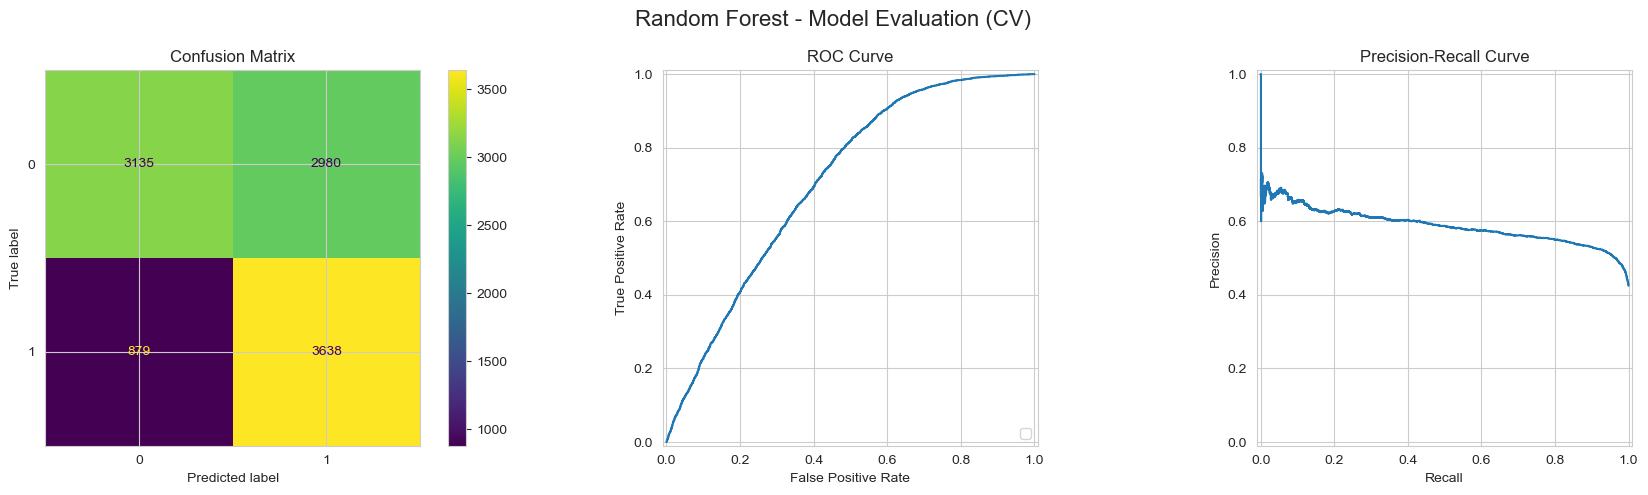

In [16]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import numpy as np

# Define CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom GridSearchCV that supports sample_weight
class GridSearchCVWithSampleWeight(GridSearchCV):
    def fit(self, X, y, **fit_params):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        fit_params['sample_weight'] = sample_weight
        return super().fit(X, y, **fit_params)

# Random Forest model and parameter grid
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_params = {
    "n_estimators": [100],
    "max_depth": [3, 5, 10],
    "min_samples_leaf": [5, 10]
}

# Fit with grid search
rf_grid = GridSearchCVWithSampleWeight(rf_model, rf_params, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
rf_grid.fit(X, y1)

# Best model
best_rf = rf_grid.best_estimator_

# Cross-validated predictions
y_pred = cross_val_predict(best_rf, X, y1, cv=cv)
y_prob = cross_val_predict(best_rf, X, y1, cv=cv, method="predict_proba")[:, 1]

# Metrics
f1 = f1_score(y1, y_pred)
bal_acc = balanced_accuracy_score(y1, y_pred)
auc = roc_auc_score(y1, y_prob)

print("--- Random Forest Evaluation for ADHD ---")
print(f"AUC = {auc:.3f}, F1 = {f1:.3f}, Balanced Accuracy = {bal_acc:.3f}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest - Model Evaluation (CV)", fontsize=16)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y1, y_pred, ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y1, y_prob)
RocCurveDisplay(fpr=fpr, tpr=tpr).plot(ax=axes[1])
axes[1].set_title("ROC Curve")

# Precision-Recall curve
prec, recall, _ = precision_recall_curve(y1, y_prob)
PrecisionRecallDisplay(precision=prec, recall=recall).plot(ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


### Next to bring in the test data.  

In [41]:
sp2test = pd.read_csv("sp2test.csv", index_col=0)
sp2test.head()

,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ADHD,DBD
10,13,Male,True,-2.604425,-1.085747,-0.210225,-0.002263,-0.000013,0.000771,-0.000895,-0.000683,-0.003673,-0.006383,-0.004227,0.006485,0.002281,1,1
12,10,Male,False,1.650894,1.544351,0.498888,-0.001953,-0.002399,0.000695,-0.000416,-0.000222,-0.000029,0.000830,0.000627,-0.000725,-0.000926,0,0
17,8,Male,True,-1.422695,0.110197,1.896701,-0.002469,-0.001309,-0.000509,-0.001462,-0.000235,0.000272,0.000458,-0.000253,-0.000729,-0.000587,1,0
21,8,Male,False,-1.521457,0.215756,0.410246,-0.001499,-0.000636,0.000513,-0.000844,-0.000341,-0.000612,-0.000445,0.004206,-0.005528,0.004070,1,0
23,19,Male,True,-0.558453,-0.735325,-0.078489,-0.002901,-0.001170,0.000512,-0.001098,-0.000619,0.000005,-0.000025,0.000101,-0.001906,-0.000375,0,0


In [43]:
#Look at the info.
info2 = sp2test.info()
print(info2)

<class 'pandas.core.frame.DataFrame'>
Index: 2658 entries, 10 to 13287
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age_at_registration_years    2658 non-null   int64  
 1   SEX                          2658 non-null   object 
 2   cognitive_impairment_latest  2658 non-null   bool   
 3   normscoreadhd                2658 non-null   float64
 4   normscoredep                 2658 non-null   float64
 5   normscoredu                  2658 non-null   float64
 6   X1                           2658 non-null   float64
 7   X2                           2658 non-null   float64
 8   X3                           2658 non-null   float64
 9   X4                           2658 non-null   float64
 10  X5                           2658 non-null   float64
 11  X6                           2658 non-null   float64
 12  X7                           2658 non-null   float64
 13  X8                   

In [45]:
#Check if you have missing data
sp2test_nas_check_per_column = sp2test.isna().any()

# Display the result
print(sp2test_nas_check_per_column)

age_at_registration_years      False
SEX                            False
cognitive_impairment_latest    False
normscoreadhd                  False
normscoredep                   False
normscoredu                    False
X1                             False
X2                             False
X3                             False
X4                             False
X5                             False
X6                             False
X7                             False
X8                             False
X9                             False
X10                            False
ADHD                           False
DBD                            False
dtype: bool


In [47]:
#Use robust scaler for the age column, and head to check 
from sklearn.preprocessing import RobustScaler
# Select the column to scale
G2 = sp2test[['age_at_registration_years']]
# Fit and transform using RobustScaler
transage2 = RobustScaler().fit(G2)
sp2test[['age_at_registration_years']] = transage2.transform(G2)
# View the result
sp2test.head()

,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ADHD,DBD
10,0.500,Male,True,-2.604425,-1.085747,-0.210225,-0.002263,-0.000013,0.000771,-0.000895,-0.000683,-0.003673,-0.006383,-0.004227,0.006485,0.002281,1,1
12,0.125,Male,False,1.650894,1.544351,0.498888,-0.001953,-0.002399,0.000695,-0.000416,-0.000222,-0.000029,0.000830,0.000627,-0.000725,-0.000926,0,0
17,-0.125,Male,True,-1.422695,0.110197,1.896701,-0.002469,-0.001309,-0.000509,-0.001462,-0.000235,0.000272,0.000458,-0.000253,-0.000729,-0.000587,1,0
21,-0.125,Male,False,-1.521457,0.215756,0.410246,-0.001499,-0.000636,0.000513,-0.000844,-0.000341,-0.000612,-0.000445,0.004206,-0.005528,0.004070,1,0
23,1.250,Male,True,-0.558453,-0.735325,-0.078489,-0.002901,-0.001170,0.000512,-0.001098,-0.000619,0.000005,-0.000025,0.000101,-0.001906,-0.000375,0,0


In [49]:
#Recheck if you have missing data
sp2test_nas_check_per_column = sp2test.isna().any()

# Display the result
print(sp2test_nas_check_per_column)

age_at_registration_years      False
SEX                            False
cognitive_impairment_latest    False
normscoreadhd                  False
normscoredep                   False
normscoredu                    False
X1                             False
X2                             False
X3                             False
X4                             False
X5                             False
X6                             False
X7                             False
X8                             False
X9                             False
X10                            False
ADHD                           False
DBD                            False
dtype: bool


In [51]:
# Next I need to convert SEX and cognitive_impairment_latest to 0/1

sp2test['SEX'] = sp2test['SEX'].map({'Male': 0, 'Female': 1})

sp2test['cognitive_impairment_latest'] = sp2test['cognitive_impairment_latest'].astype(int)

sp2test.head()

,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,ADHD,DBD
10,0.500,0,1,-2.604425,-1.085747,-0.210225,-0.002263,-0.000013,0.000771,-0.000895,-0.000683,-0.003673,-0.006383,-0.004227,0.006485,0.002281,1,1
12,0.125,0,0,1.650894,1.544351,0.498888,-0.001953,-0.002399,0.000695,-0.000416,-0.000222,-0.000029,0.000830,0.000627,-0.000725,-0.000926,0,0
17,-0.125,0,1,-1.422695,0.110197,1.896701,-0.002469,-0.001309,-0.000509,-0.001462,-0.000235,0.000272,0.000458,-0.000253,-0.000729,-0.000587,1,0
21,-0.125,0,0,-1.521457,0.215756,0.410246,-0.001499,-0.000636,0.000513,-0.000844,-0.000341,-0.000612,-0.000445,0.004206,-0.005528,0.004070,1,0
23,1.250,0,1,-0.558453,-0.735325,-0.078489,-0.002901,-0.001170,0.000512,-0.001098,-0.000619,0.000005,-0.000025,0.000101,-0.001906,-0.000375,0,0


In [53]:
#Create an input data array X (with all columns except ADHD and DBD), and the output arrays y1 and y2. Set the output array to float64 type.
# Modify code as required
#X, y = data.iloc[:,:-1].values, data.iloc[:,-1].values
X2 = sp2test.iloc[:, :-2].values  # Select all columns except the last two
y21 = sp2test.iloc[:, -2].values  # Second to last column [ADHD]
y22 = sp2test.iloc[:, -1].values  # Last column [DBD]

y21 = y21.astype('int')
y22 = y22.astype('int')

# Check the shape
X2.shape

(2658, 16)

Testing only the random forest model:

--- Random Forest Evaluation on Test Set ---
AUC = 0.703, F1 = 0.667, Balanced Accuracy = 0.652


C:\Users\niran\anaconda3\Lib\site-packages\sklearn\metrics\_plot\roc_curve.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


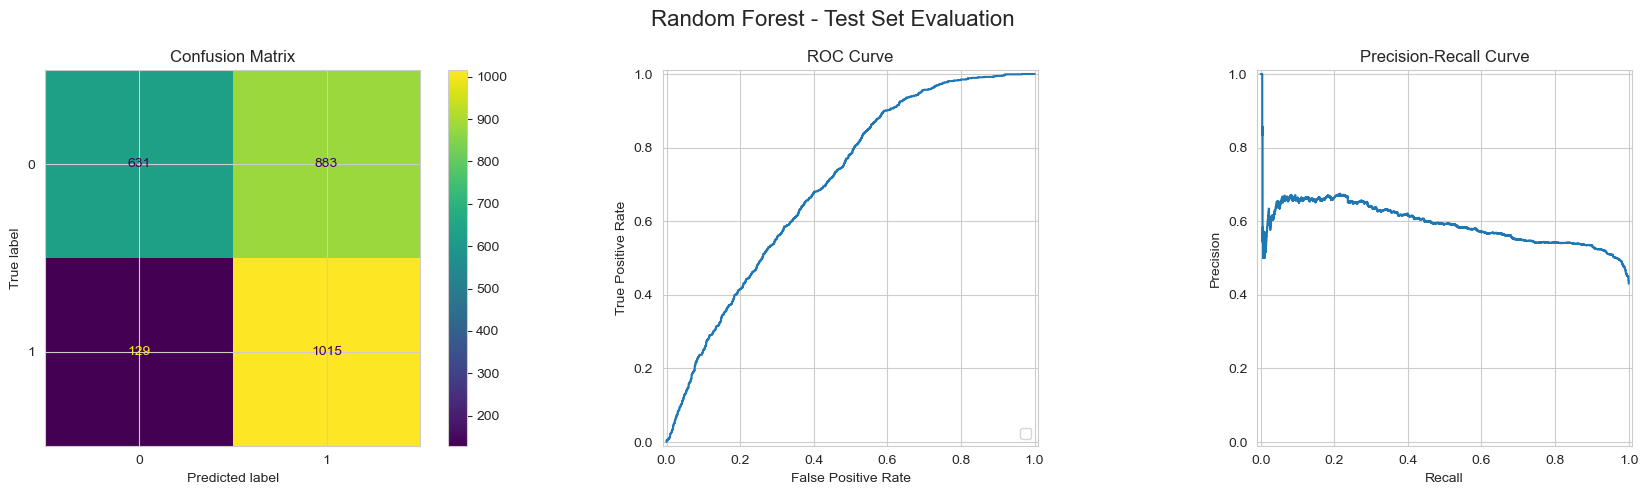

In [61]:
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Predict on test set
y21_pred = best_rf.predict(X2)
y21_prob = best_rf.predict_proba(X2)[:, 1]

# Compute metrics
f1_test = f1_score(y21, y21_pred)
bal_acc_test = balanced_accuracy_score(y21, y21_pred)
auc_test = roc_auc_score(y21, y21_prob)

print("--- Random Forest Evaluation on Test Set ---")
print(f"AUC = {auc_test:.3f}, F1 = {f1_test:.3f}, Balanced Accuracy = {bal_acc_test:.3f}")

# Plot confusion matrix, ROC curve, and PR curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest - Test Set Evaluation", fontsize=16)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y21, y21_pred, ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y21, y21_prob)
RocCurveDisplay(fpr=fpr, tpr=tpr).plot(ax=axes[1])
axes[1].set_title("ROC Curve")

# Precision-Recall curve
prec, recall, _ = precision_recall_curve(y21, y21_prob)
PrecisionRecallDisplay(precision=prec, recall=recall).plot(ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


To compare prediction across sex: 

In [106]:
#print(type(X2))
feature_names = ['age_at_registration_years', 'SEX', 'cognitive_impairment_latest',
                 'normscoreadhd', 'normscoredep', 'normscoredu',
                 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
X2 = pd.DataFrame(X2, columns=feature_names)  
X2.head()

,age_at_registration_years,SEX,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.500,0.0,1.0,-2.604425,-1.085747,-0.210225,-0.002263,-0.000013,0.000771,-0.000895,-0.000683,-0.003673,-0.006383,-0.004227,0.006485,0.002281
1,0.125,0.0,0.0,1.650894,1.544351,0.498888,-0.001953,-0.002399,0.000695,-0.000416,-0.000222,-0.000029,0.000830,0.000627,-0.000725,-0.000926
2,-0.125,0.0,1.0,-1.422695,0.110197,1.896701,-0.002469,-0.001309,-0.000509,-0.001462,-0.000235,0.000272,0.000458,-0.000253,-0.000729,-0.000587
3,-0.125,0.0,0.0,-1.521457,0.215756,0.410246,-0.001499,-0.000636,0.000513,-0.000844,-0.000341,-0.000612,-0.000445,0.004206,-0.005528,0.004070
4,1.250,0.0,1.0,-0.558453,-0.735325,-0.078489,-0.002901,-0.001170,0.000512,-0.001098,-0.000619,0.000005,-0.000025,0.000101,-0.001906,-0.000375


C:\Users\niran\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\niran\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\niran\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\niran\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Sex=0: AUC=0.707, PR AUC=0.609, F1=0.680, Balanced Acc=0.654
Sex=1: AUC=0.681, PR AUC=0.517, F1=0.605, Balanced Acc=0.640


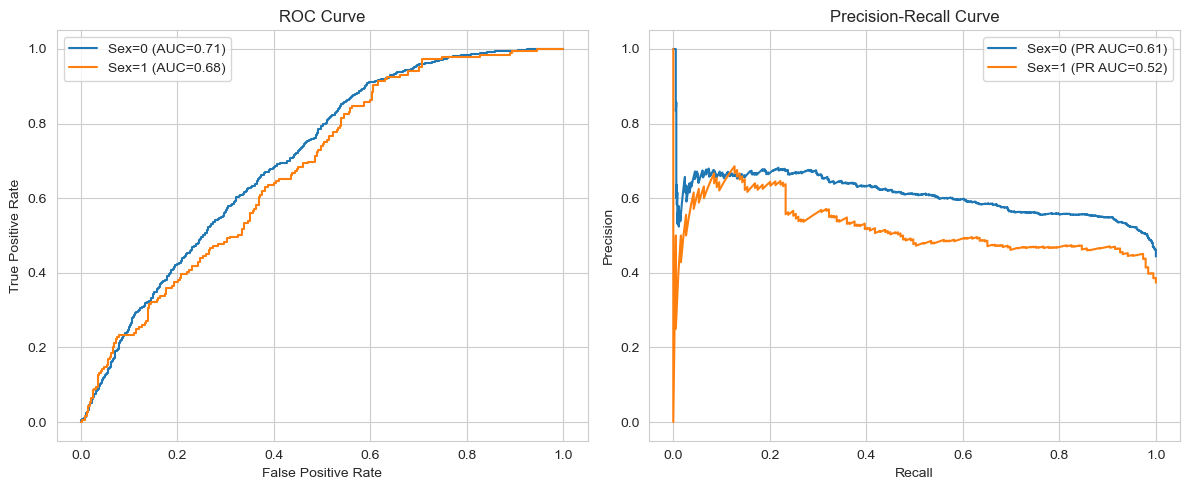

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, balanced_accuracy_score,
    roc_curve, precision_recall_curve, auc
)

plt.figure(figsize=(12, 5))

# Prepare subplots: 1 row, 2 columns (ROC and PR)
for i, sex in enumerate([0, 1]):
    sex_mask = X2['SEX'] == sex
    subset_X = X2[sex_mask]
    subset_y = y21[sex_mask]

    y_pred_proba = best_rf.predict_proba(subset_X[feature_names])[:, 1]
    y_pred = best_rf.predict(subset_X[feature_names])

    # Compute metrics
    auc_score = roc_auc_score(subset_y, y_pred_proba)
    f1 = f1_score(subset_y, y_pred)
    bal_acc = balanced_accuracy_score(subset_y, y_pred)

    # ROC curve
    fpr, tpr, _ = roc_curve(subset_y, y_pred_proba)
    # PR curve
    precision, recall, _ = precision_recall_curve(subset_y, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Plot ROC
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"Sex={sex} (AUC={auc_score:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

    # Plot PR
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"Sex={sex} (PR AUC={pr_auc:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()

    # Print metrics
    print(f"Sex={sex}: AUC={auc_score:.3f}, PR AUC={pr_auc:.3f}, F1={f1:.3f}, Balanced Acc={bal_acc:.3f}")

plt.tight_layout()
plt.show()
#KIV: 1=female, 0=male.

### Model explainability

Next we want to have a look at model interpretability and explainability, starting with ADHD. This section is based on the MEE course by Cambridge Spark. 
What is reasonable is global (vs local) explainability with SHAP (vs Permutation Feature Importance).  

In [132]:
#!pip install shap

In [134]:
#import pandas as pd
#import numpy as np
#from sklearn.model_selection import train_test_split
import shap
shap.initjs() # need to load JS vis in the notebook for shap to display

Lecture note: 'SHAP has a generic explainer that works for any model, called KernelExplainer. This explainer requires an arbitrary model and some training data in order to calibrate itself. This fully agnostic method is slow and only computes an approximation of the SHAP values, so shap also provides special explainers that are optimised for specific classes of models. The TreeExplainer is optimised for tree based models, and is what we will use here with LightGBM. TreeExplainer also has the advantage that it can "calibrate" itself using properties of trees directly, instead of estimating values from an external dataset, that means that we only need to provide a model and shap does the rest.'

My options: use TreeExplainer on the premiss that I am stacking on RF, or use KernelExplainer, calibrate with training data and evaluate test data. Option 1: 

In [137]:
#create a SHAP tree explainer object from the model
explainer = shap.TreeExplainer(best_rf) #model=best_rf


In [158]:
#Now that we have an explainer object, we can start using it to compute SHAP values on our data. Compute the SHAP values on the test set.
shap_values = explainer.shap_values(X2[feature_names]) 

100%|===================| 5314/5316 [01:11<00:00]        

In [162]:
#shap_values is an array, we can check its shape by running the code snippet below.
shap_values.shape

(2658, 16, 2)

Shap_values is an array containing the SHAP value associated with each of the samples and features.
If you use the model agnostic KernelExplainer, those values will be expressed as probabilities. With the TreeExplainer though, the unit will be specific to the library/model you are using. We can check this with the following command:

In [164]:
explainer.model.tree_output

'probability'

SHAP’s TreeExplainer for tree-based models (like RandomForestClassifier) by default operates in probability space, not log-odds.
So instead of computing average log-odds, you should compare the mean probability:

In [167]:
import shap
import numpy as np

# Compute mean predicted probability for class 1 on training set
y_pred = best_rf.predict_proba(X)[:, 1]
average_prob = np.mean(y_pred)
print("Average predicted probability (class 1):", average_prob)

# Create SHAP explainer
explainer = shap.Explainer(best_rf, X)

# Get SHAP base value
base_value = explainer.expected_value
print("SHAP base value:", base_value)


Average predicted probability (class 1): 0.5334887799870537
SHAP base value: [0.46896844 0.53103156]


KIV SHAP can also be used for local explanation. See Academy notes for code. Global SHAP explanations are for the model overall.
Generate a scatter plot of the test set SHAP values:

In [170]:
print("SHAP shape:", shap_values[1].shape)
print("X2[features] shape:", X2[feature_names].shape)

SHAP shape: (16, 2)
X2[features] shape: (2658, 16)


<Figure size 640x480 with 0 Axes>

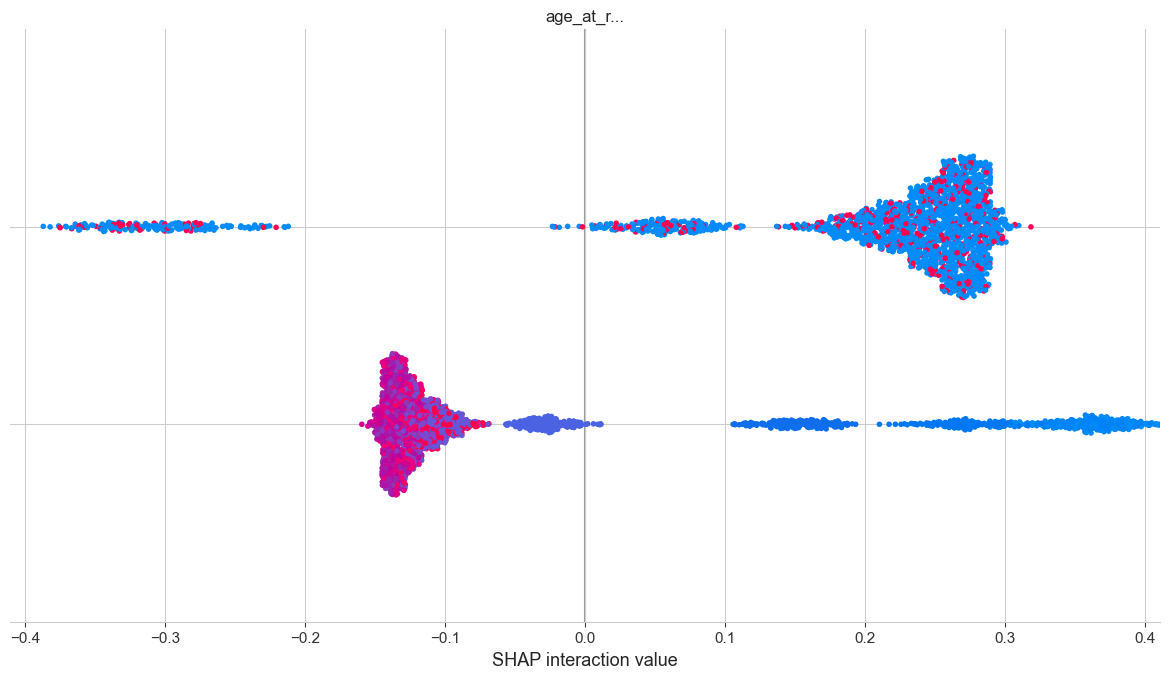

In [172]:
shap.summary_plot(shap_values, X2) 

Next, generate a bar chart of the average magnitude SHAP values per feature.

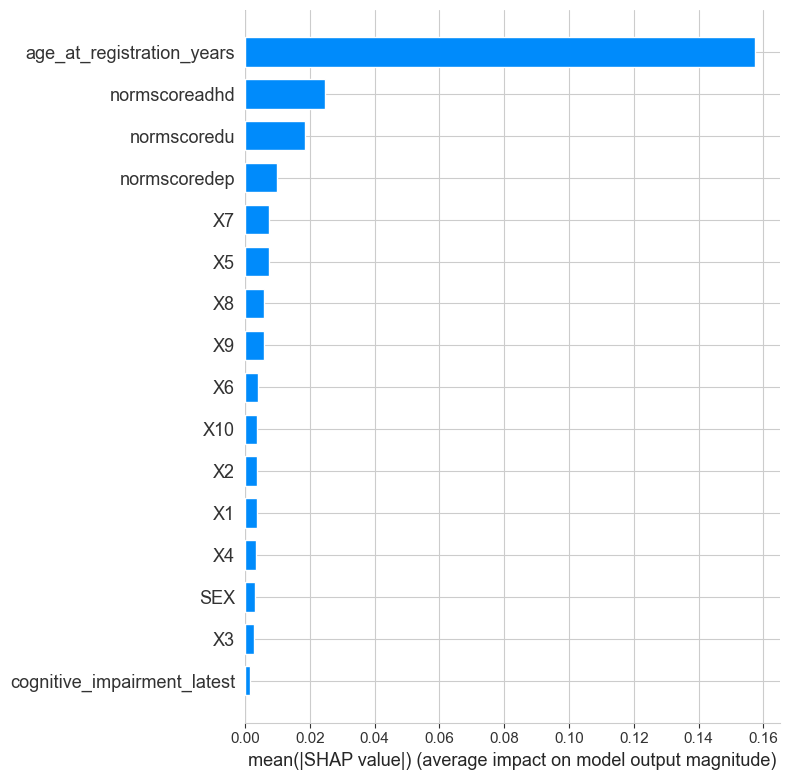

In [176]:
#shap.summary_plot(shap_values, X2[feature_names], plot_type="bar")
shap.summary_plot(shap_values[:, :, 1], X2[feature_names], plot_type="bar")

Finally, dependence plots. Course notes:'
SHAP dependence plots show the SHAP values for one particular feature for all samples in the dataset. The vertical dispersion of SHAP values at a single value of the feature is driven by interaction effects between that feature and the model outcome. A second feature (represented by the colour) is chosen to highlight possible interactions between the two features and the model outcome'.
rall.

Run the following code snippet to generate the SHAP dependence pylots for our model.

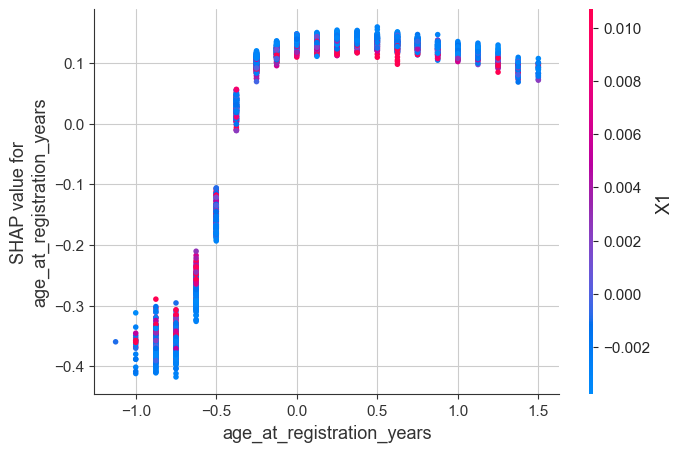

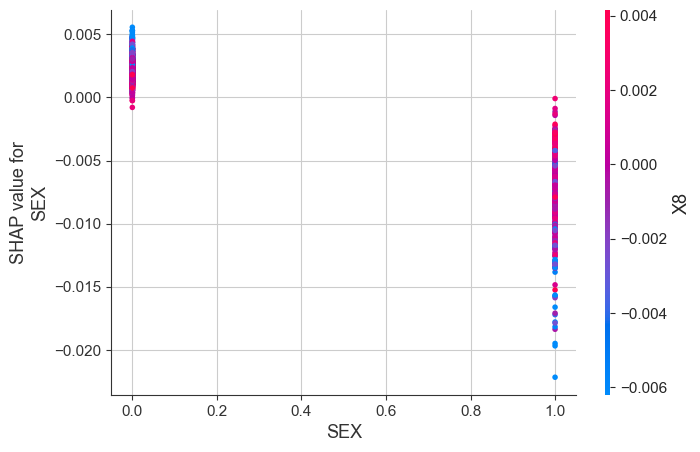

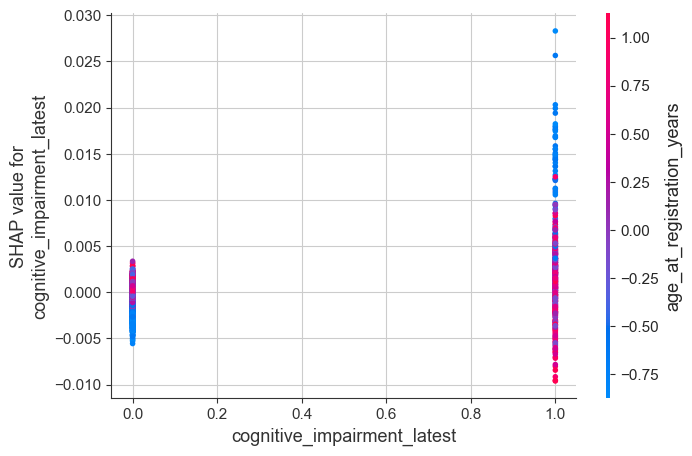

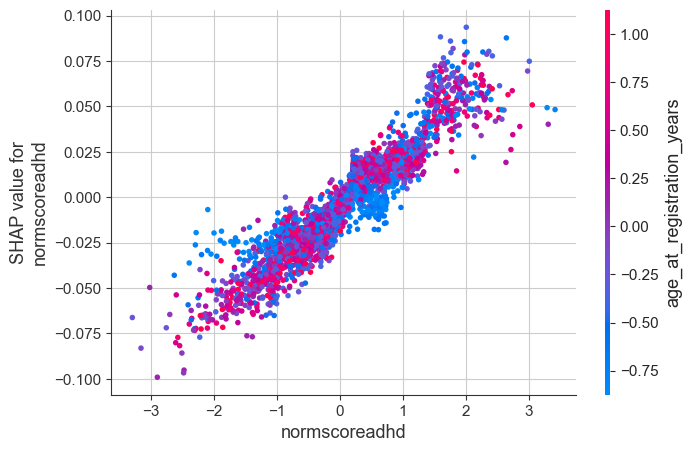

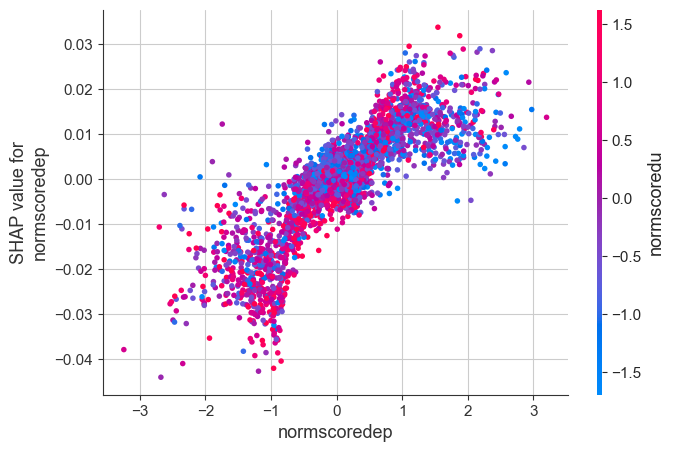

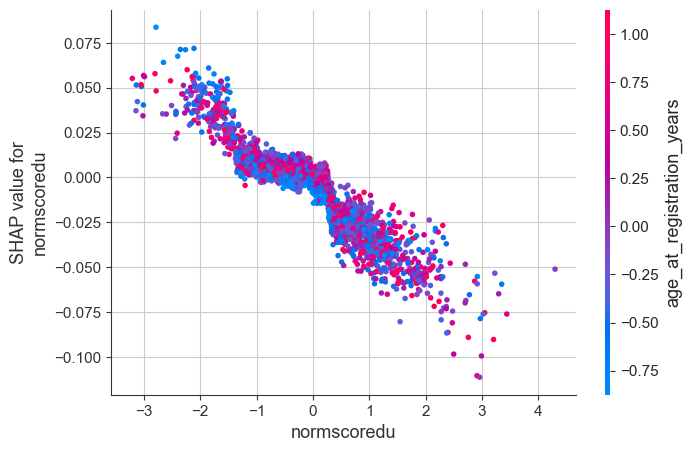

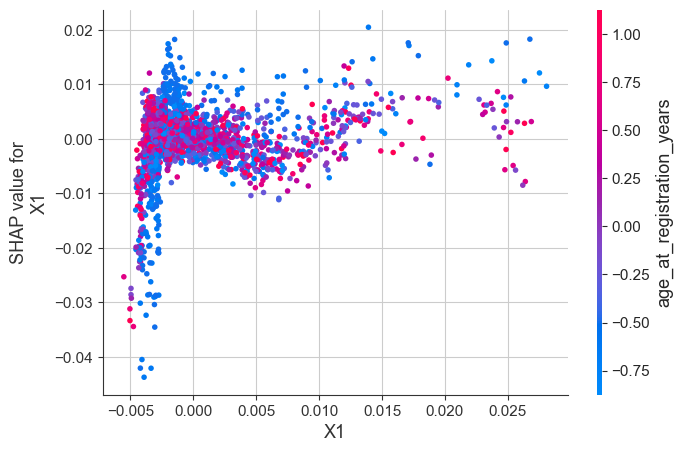

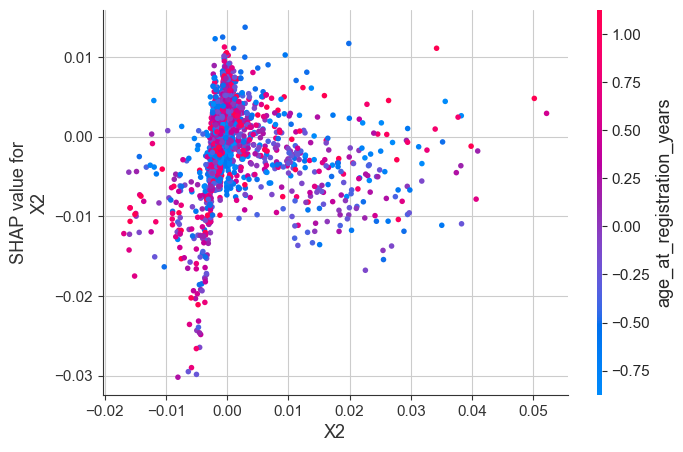

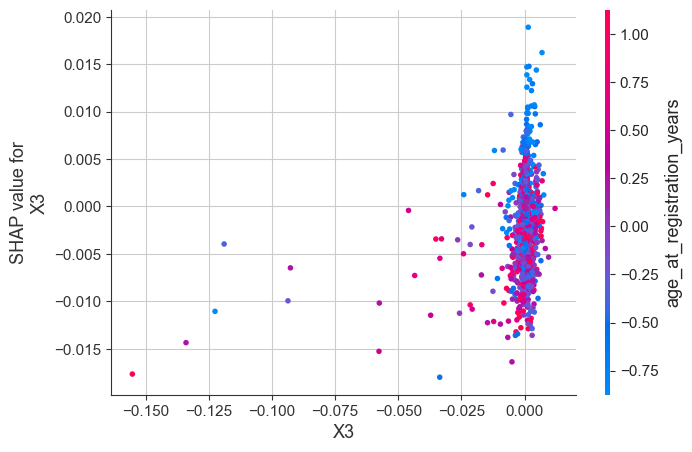

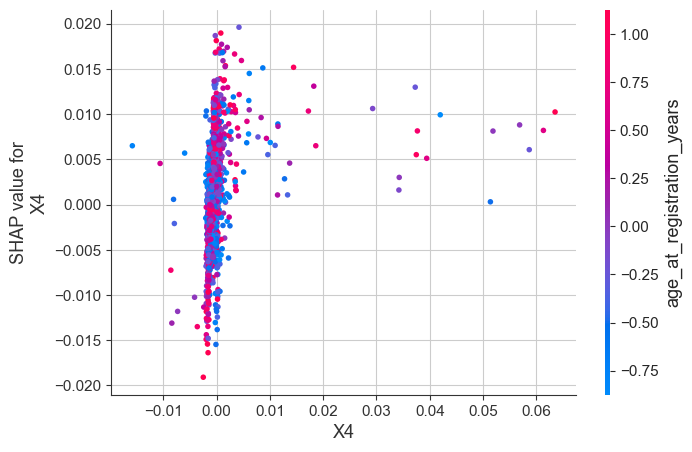

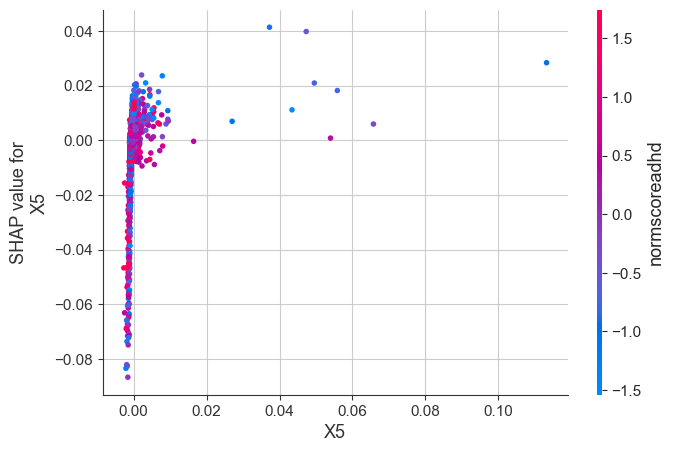

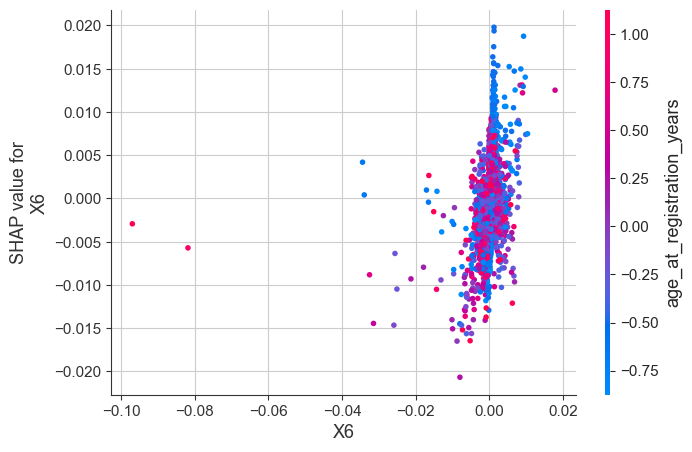

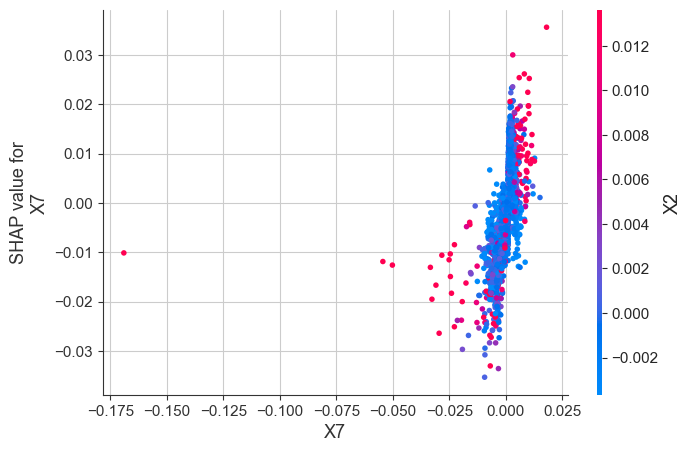

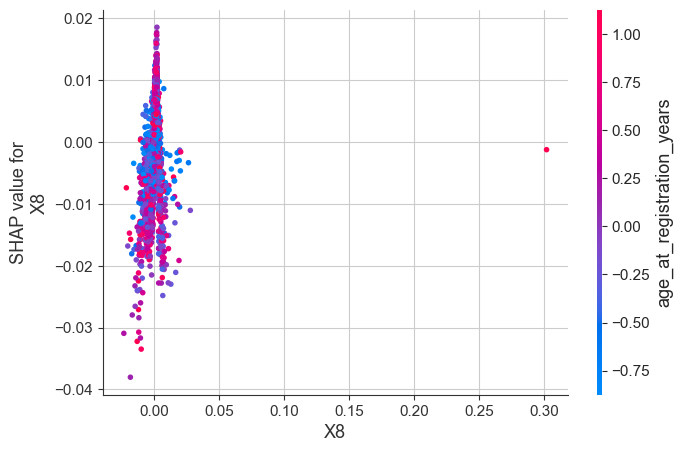

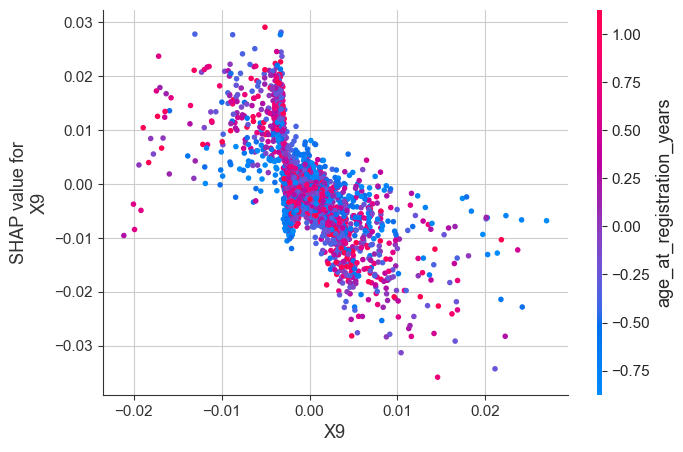

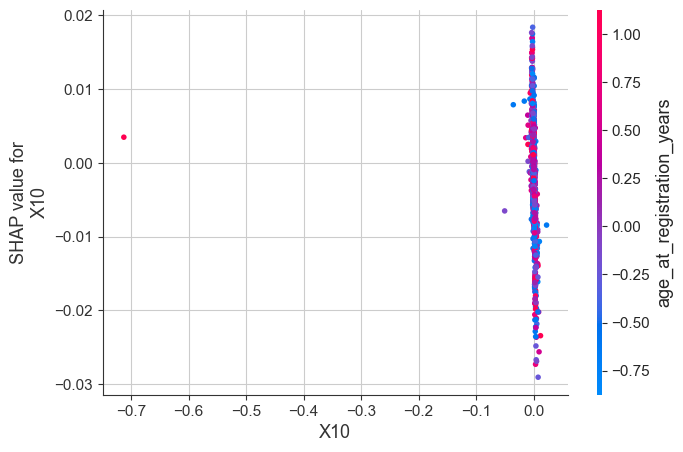

In [181]:
# Compute SHAP values using TreeExplainer or Explainer (already done previously)
# Assume shap_values shape is (n_samples, n_features, 2)
shap_values_class1 = shap_values[:, :, 1]  # Select SHAP values for class 1 (positive class)

# Generate SHAP dependence plots for each feature
for name in feature_names:
    shap.dependence_plot(
        name,
        shap_values_class1,
        X2[feature_names],              # Feature matrix used during SHAP calculation
        display_features=X2[feature_names]  # For readable tick labels, etc.
    )


Next is to use the kernel explainer, which is model agnostic. Not required for our tree-based model. 

In [ ]:
# 1. Define a prediction function for SHAP
f = lambda x: model_stack.predict_proba(x)[:, 1]

# 2. Use a representative background sample from the training data
background = shap.kmeans(X, 100)  

# 3. Create the KernelExplainer
explainer = shap.KernelExplainer(f, background)

# 4. Explain the predictions on test data (e.g., first 100 instances)
X2_subset = X2.iloc[:100]
shap_values = explainer.shap_values(X2_subset)

# 5. Plot summary and force plots
shap.summary_plot(shap_values, X2_subset, feature_names=X2.columns)


### Next to bring in the African ancestry data.  

In [19]:
sp2afr = pd.read_csv("spafr2final.csv", index_col=0)
sp2afr.head()

,age_at_eval_years,sex,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,behav_adhd
1,11,Male,True,0.049398,-0.210303,-0.371093,0.027811,0.001927,-0.006053,0.000733,0.007491,-0.003921,-0.007698,-0.023868,-0.003915,0.001392,1
2,8,Male,False,1.272256,-1.352872,-0.927665,0.024577,-0.006125,-0.004408,0.001362,0.005906,0.004170,-0.005081,-0.016028,-0.003973,0.007440,1
3,12,Male,True,2.133915,-0.778377,-0.785307,0.030801,0.000826,-0.007996,0.000929,0.007798,-0.001924,-0.004883,-0.020113,-0.008108,0.001773,1
4,19,Male,False,0.005127,0.490523,0.021962,0.036593,0.000501,-0.007671,0.000908,0.009595,-0.002742,-0.003239,-0.022767,-0.009707,0.001119,1
5,15,Male,False,-0.434946,-0.457805,1.638588,0.026352,-0.004314,-0.004416,0.001009,0.006537,0.003511,-0.004706,-0.019119,-0.007647,0.002344,1


In [20]:
#Look at the info.
info3 = sp2afr.info()
print(info3)

<class 'pandas.core.frame.DataFrame'>
Index: 2489 entries, 1 to 2489
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age_at_eval_years            2489 non-null   int64  
 1   sex                          2489 non-null   object 
 2   cognitive_impairment_latest  2489 non-null   bool   
 3   normscoreadhd                2489 non-null   float64
 4   normscoredep                 2489 non-null   float64
 5   normscoredu                  2489 non-null   float64
 6   V1                           2489 non-null   float64
 7   V2                           2489 non-null   float64
 8   V3                           2489 non-null   float64
 9   V4                           2489 non-null   float64
 10  V5                           2489 non-null   float64
 11  V6                           2489 non-null   float64
 12  V7                           2489 non-null   float64
 13  V8                     

In [21]:
#Check if you have missing data
sp2afr_nas_check_per_column = sp2afr.isna().any()

# Display the result
print(sp2afr_nas_check_per_column)

age_at_eval_years              False
sex                            False
cognitive_impairment_latest    False
normscoreadhd                  False
normscoredep                   False
normscoredu                    False
V1                             False
V2                             False
V3                             False
V4                             False
V5                             False
V6                             False
V7                             False
V8                             False
V9                             False
V10                            False
behav_adhd                     False
dtype: bool


In [22]:
#Use robust scaler for the age column, and head to check 
from sklearn.preprocessing import RobustScaler
# Select the column to scale
G3 = sp2afr[['age_at_eval_years']]
# Fit and transform using RobustScaler
transage3 = RobustScaler().fit(G3)
sp2afr[['age_at_eval_years']] = transage3.transform(G3)
# View the result
sp2afr.head()

,age_at_eval_years,sex,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,behav_adhd
1,0.428571,Male,True,0.049398,-0.210303,-0.371093,0.027811,0.001927,-0.006053,0.000733,0.007491,-0.003921,-0.007698,-0.023868,-0.003915,0.001392,1
2,0.000000,Male,False,1.272256,-1.352872,-0.927665,0.024577,-0.006125,-0.004408,0.001362,0.005906,0.004170,-0.005081,-0.016028,-0.003973,0.007440,1
3,0.571429,Male,True,2.133915,-0.778377,-0.785307,0.030801,0.000826,-0.007996,0.000929,0.007798,-0.001924,-0.004883,-0.020113,-0.008108,0.001773,1
4,1.571429,Male,False,0.005127,0.490523,0.021962,0.036593,0.000501,-0.007671,0.000908,0.009595,-0.002742,-0.003239,-0.022767,-0.009707,0.001119,1
5,1.000000,Male,False,-0.434946,-0.457805,1.638588,0.026352,-0.004314,-0.004416,0.001009,0.006537,0.003511,-0.004706,-0.019119,-0.007647,0.002344,1


In [23]:
#Recheck if you have missing data
sp2afr_nas_check_per_column = sp2afr.isna().any()

# Display the result
print(sp2afr_nas_check_per_column)

age_at_eval_years              False
sex                            False
cognitive_impairment_latest    False
normscoreadhd                  False
normscoredep                   False
normscoredu                    False
V1                             False
V2                             False
V3                             False
V4                             False
V5                             False
V6                             False
V7                             False
V8                             False
V9                             False
V10                            False
behav_adhd                     False
dtype: bool


In [24]:
# Next I need to convert SEX and cognitive_impairment_latest to 0/1

sp2afr['sex'] = sp2afr['sex'].map({'Male': 0, 'Female': 1})

sp2afr['cognitive_impairment_latest'] = sp2afr['cognitive_impairment_latest'].astype(int)

sp2afr.head()

,age_at_eval_years,sex,cognitive_impairment_latest,normscoreadhd,normscoredep,normscoredu,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,behav_adhd
1,0.428571,0,1,0.049398,-0.210303,-0.371093,0.027811,0.001927,-0.006053,0.000733,0.007491,-0.003921,-0.007698,-0.023868,-0.003915,0.001392,1
2,0.000000,0,0,1.272256,-1.352872,-0.927665,0.024577,-0.006125,-0.004408,0.001362,0.005906,0.004170,-0.005081,-0.016028,-0.003973,0.007440,1
3,0.571429,0,1,2.133915,-0.778377,-0.785307,0.030801,0.000826,-0.007996,0.000929,0.007798,-0.001924,-0.004883,-0.020113,-0.008108,0.001773,1
4,1.571429,0,0,0.005127,0.490523,0.021962,0.036593,0.000501,-0.007671,0.000908,0.009595,-0.002742,-0.003239,-0.022767,-0.009707,0.001119,1
5,1.000000,0,0,-0.434946,-0.457805,1.638588,0.026352,-0.004314,-0.004416,0.001009,0.006537,0.003511,-0.004706,-0.019119,-0.007647,0.002344,1


C:\Users\ao508\AppData\Local\Temp\ipykernel_1836\4117614605.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].astype(str), ax=axes[i], palette='Set2')  # Convert to string for countplot
C:\Users\ao508\AppData\Local\Temp\ipykernel_1836\4117614605.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].astype(str), ax=axes[i], palette='Set2')  # Convert to string for countplot
C:\Users\ao508\AppData\Local\Temp\ipykernel_1836\4117614605.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col].astype(str), ax=axes

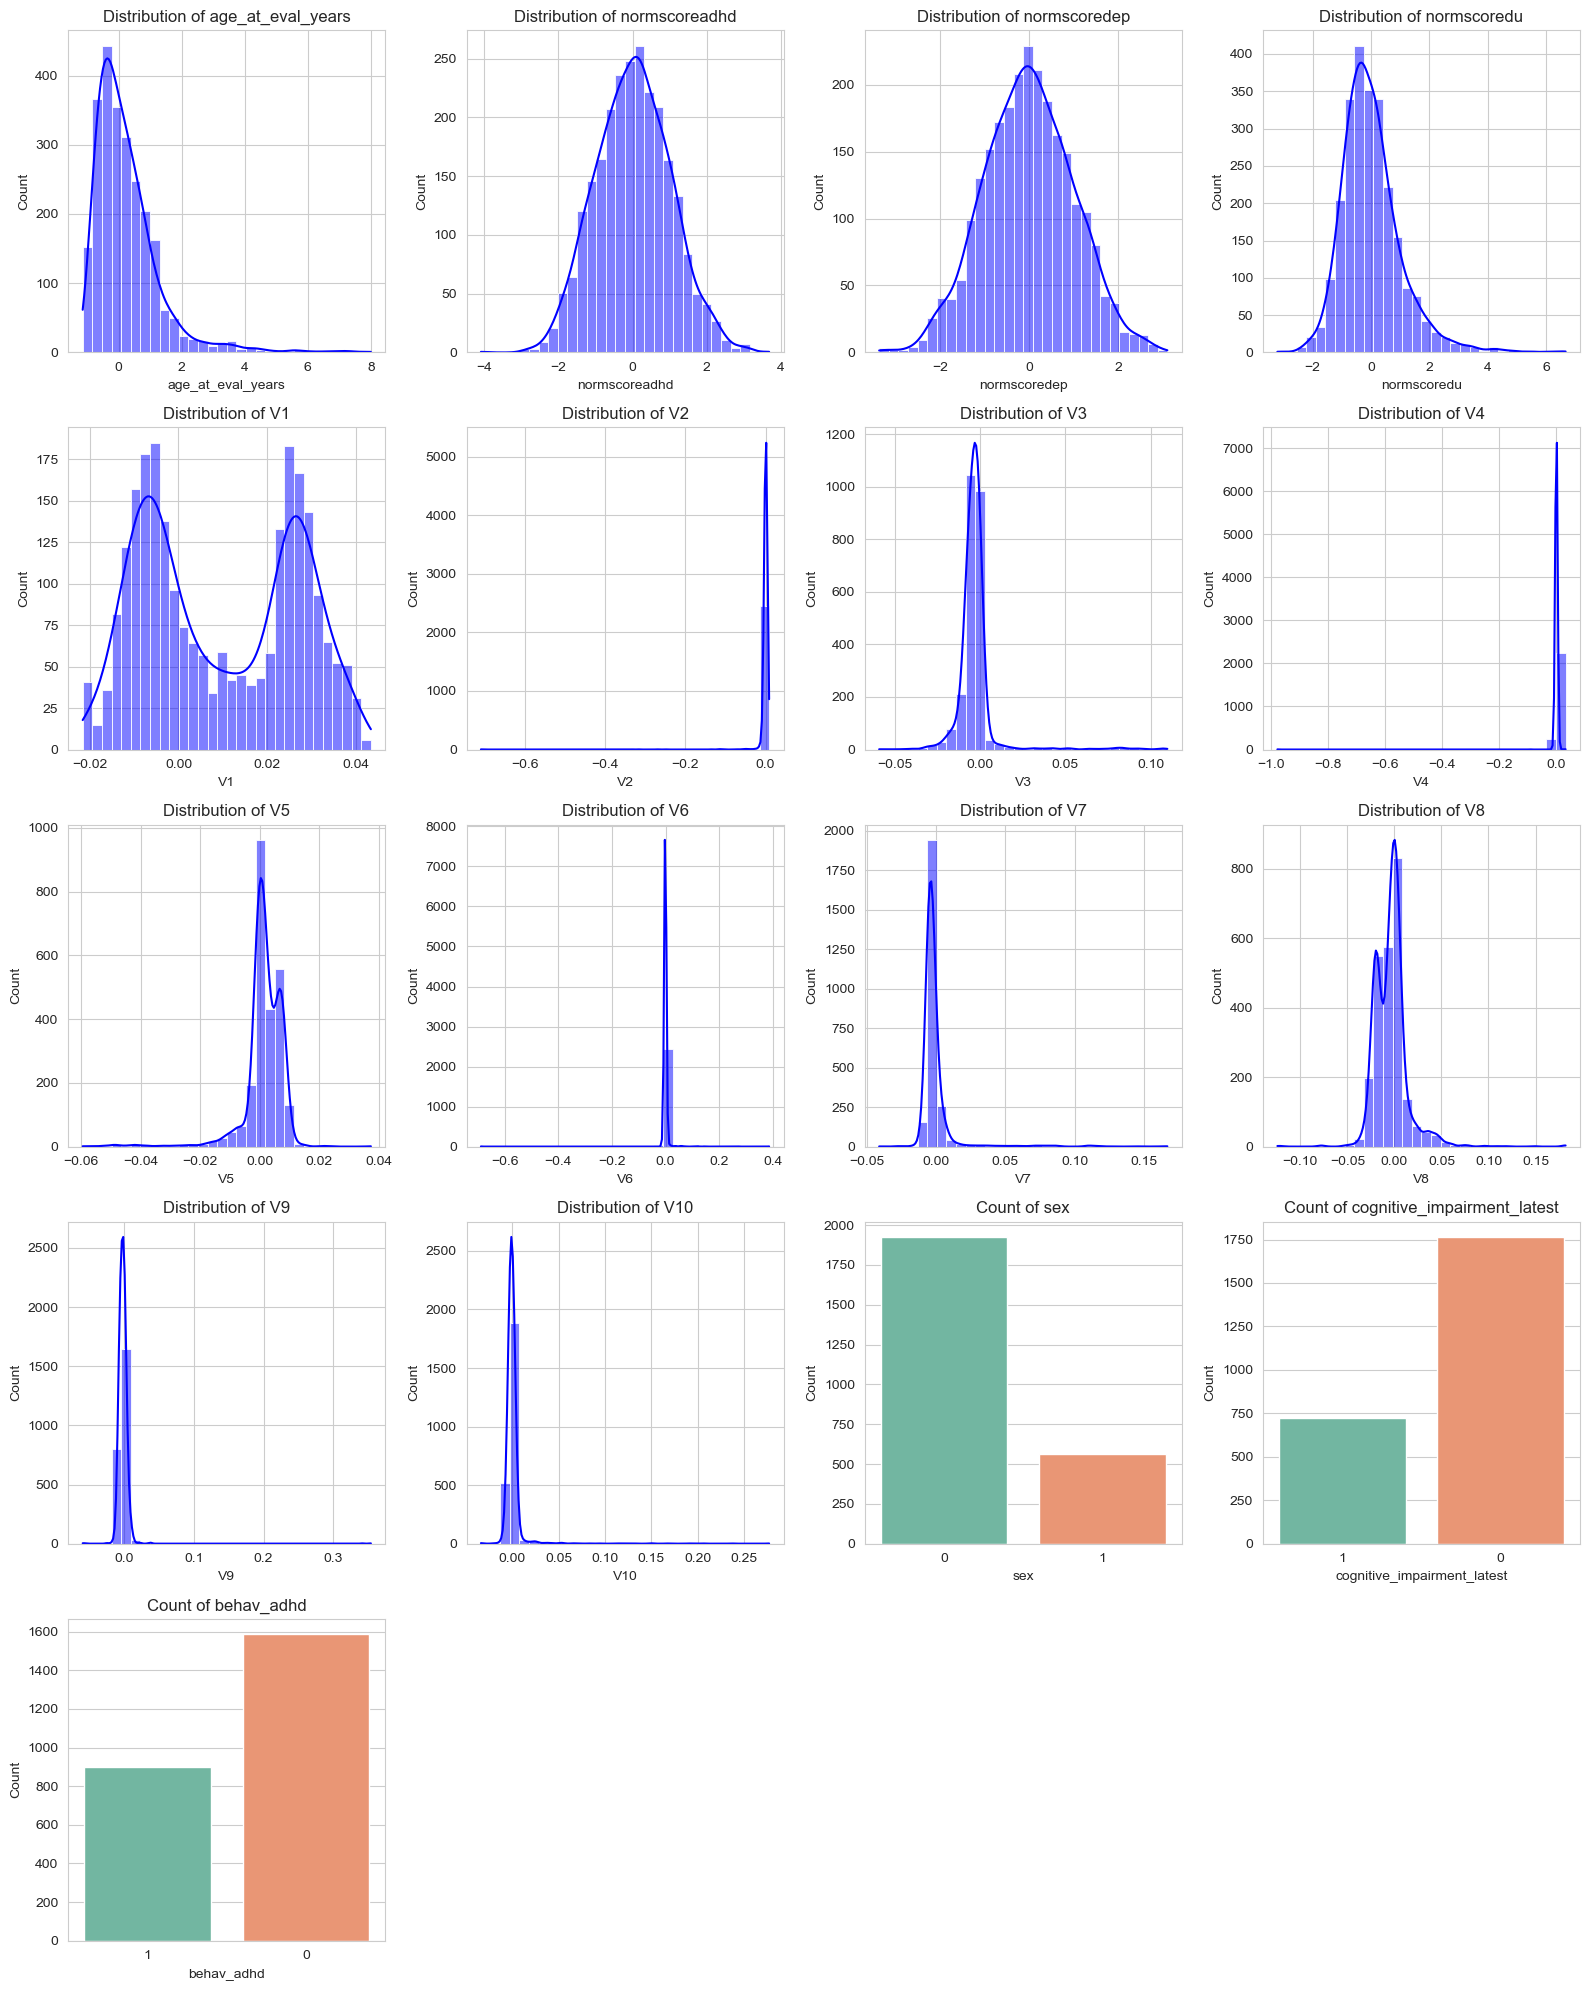

In [25]:
#Plot distributions of all variables

def plot_all_distributions(df, bins=30):
    numeric_cols = df.select_dtypes(include=['number']).columns
    binary_cols = [col for col in numeric_cols if df[col].nunique() == 2]
    continuous_cols = [col for col in numeric_cols if df[col].nunique() > 2]
    
    total_plots = len(continuous_cols) + len(binary_cols)
    if total_plots == 0:
        print("No columns to plot.")
        return

    # Define number of columns for subplots
    n_cols = 4
    n_rows = (total_plots // n_cols) + (total_plots % n_cols > 0)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    i = 0
    # Plot continuous distributions
    for col in continuous_cols:
        sns.histplot(df[col], ax=axes[i], bins=bins, kde=True, color='blue')
        axes[i].set_title(f'Distribution of {col}')
        i += 1

    # Plot binary distributions as count plots
    for col in binary_cols:
        sns.countplot(x=df[col].astype(str), ax=axes[i], palette='Set2')  # Convert to string for countplot
        axes[i].set_title(f'Count of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        i += 1

    # Hide any unused axes
    for j in range(i, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_distributions(sp2afr)



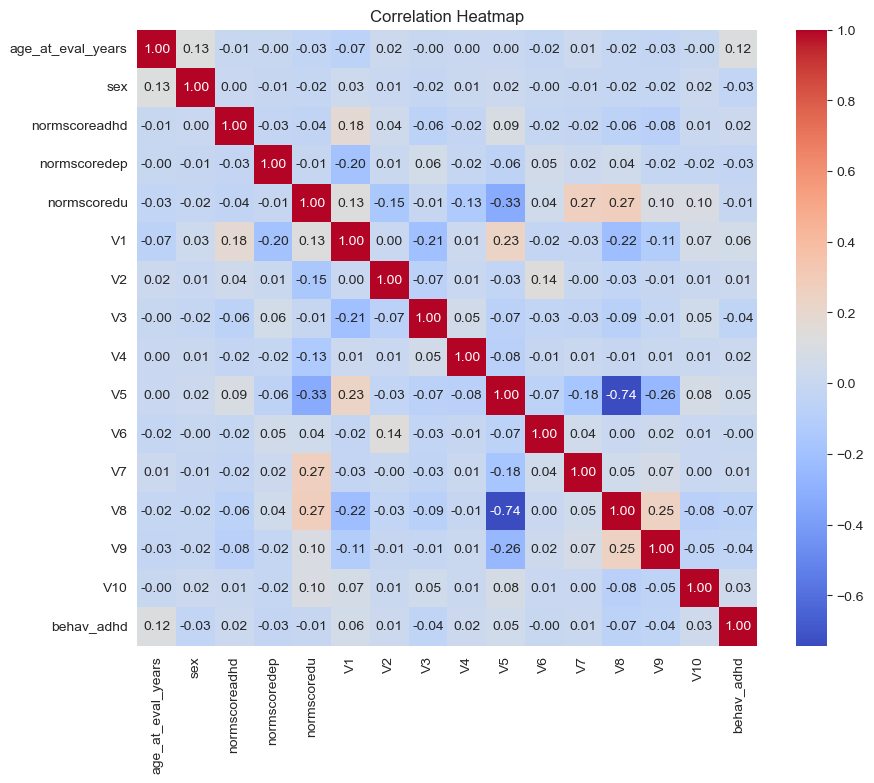

In [26]:
def plot_correlation_heatmap(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    if len(numeric_cols) < 2:
        print("Not enough numeric columns to calculate correlations.")
        return
    
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()

plot_correlation_heatmap(sp2afr)

In [27]:
#Create an input data array X (with all columns except ADHD and DBD), and the output arrays y1 and y2. Set the output array to float64 type.
# Modify code as required
#X, y = data.iloc[:,:-1].values, data.iloc[:,-1].values
X3 = sp2afr.iloc[:, :-1].values  # Select all columns except the last one
y3 = sp2afr.iloc[:, -1].values  # Last column [ADHD]
y3 = y3.astype('int')

# Check the shape
X3.shape

(2489, 16)

Now we're ready to run our model. 


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


--- Random Forest Evaluation on African Ancestry ---
AUC = 0.649, F1 = 0.587, Balanced Accuracy = 0.625


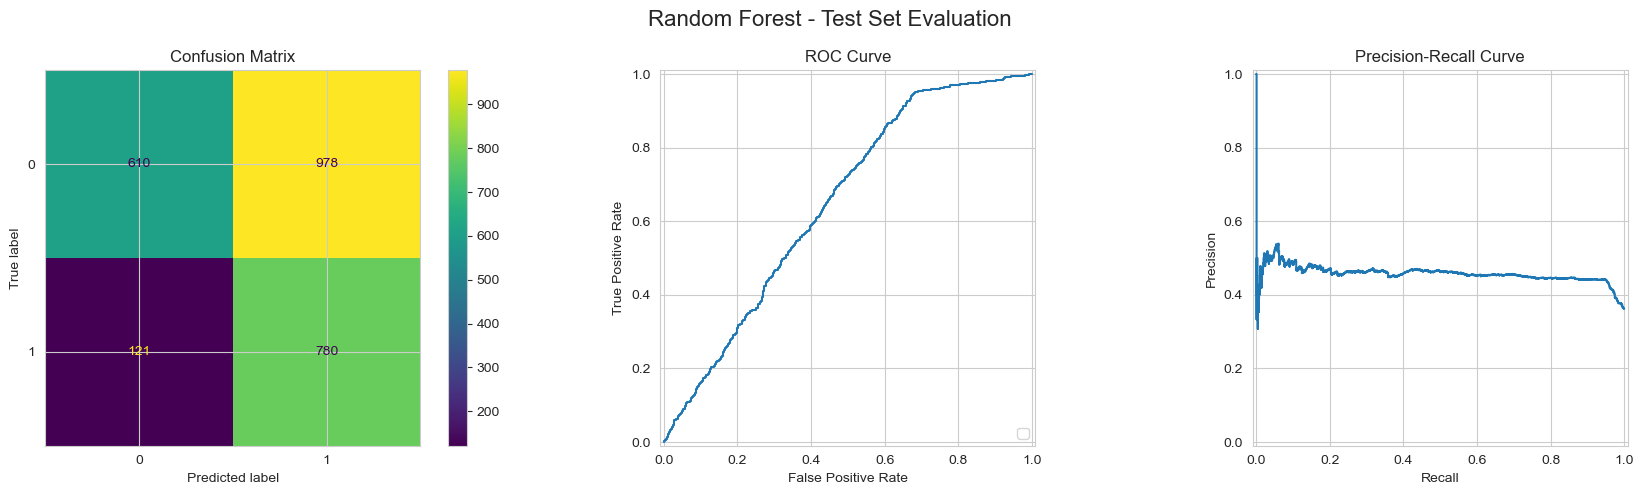

In [28]:
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Predict on African ancestry
y3_pred = best_rf.predict(X3)
y3_prob = best_rf.predict_proba(X3)[:, 1]

# Compute metrics
f1_test = f1_score(y3, y3_pred)
bal_acc_test = balanced_accuracy_score(y3, y3_pred)
auc_test = roc_auc_score(y3, y3_prob)

print("--- Random Forest Evaluation on African Ancestry ---")
print(f"AUC = {auc_test:.3f}, F1 = {f1_test:.3f}, Balanced Accuracy = {bal_acc_test:.3f}")

# Plot confusion matrix, ROC curve, and PR curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest - Test Set Evaluation", fontsize=16)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y3, y3_pred, ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y3, y3_prob)
RocCurveDisplay(fpr=fpr, tpr=tpr).plot(ax=axes[1])
axes[1].set_title("ROC Curve")

# Precision-Recall curve
prec, recall, _ = precision_recall_curve(y3, y3_prob)
PrecisionRecallDisplay(precision=prec, recall=recall).plot(ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


In [31]:
#!pip install shap

In [32]:
import shap
shap.initjs()

In [33]:
#create a SHAP tree explainer object from the model
explainer = shap.TreeExplainer(best_rf) #model=best_rf

In [34]:
feature_names2 = ['age_at_eval_years', 'sex', 'cognitive_impairment_latest',
                 'normscoreadhd', 'normscoredep', 'normscoredu',
                 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']

In [36]:
#Now that we have an explainer object, we can start using it to compute SHAP values on our data. Compute the SHAP values on the African set.
X3_df = pd.DataFrame(X3, columns=feature_names2)
shap_values = explainer.shap_values(X3_df) 

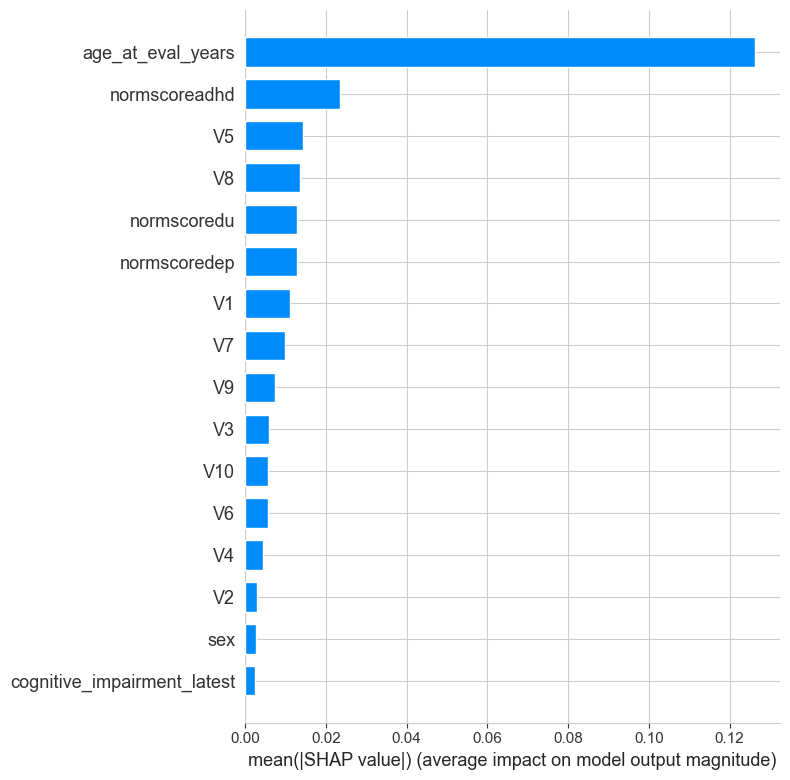

In [37]:
#shap.summary_plot(shap_values, X2[feature_names], plot_type="bar")
shap.summary_plot(shap_values[:, :, 1], X3_df, plot_type="bar")